# Annotate the bone-marrow immune microenvironment

**Biology rationale.** Resolving hematopoietic populations is necessary to identify the immune cells that interact with amyloidogenic plasma cells.

**Aim.** Apply reference-based annotation and per-cell-type analyses to define the bone-marrow microenvironment.

**Data input.** `./sce1_TME.rds`, `Figs9a.pdf`, `Figs9b.pdf`, `TME.noverlabel.csv`, `sce1_ALl19clustermeta.data.csv`



**Data outputs.** Processed objects, statistical summaries, and visualizations generated in the notebook.

## 1. Packages and setup


In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)
library(SingleR)
library(celldex)
library(scCustomize)
set.seed(123)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
plotCellTypePropscustom<-function (x = NULL, clusters = NULL, sample = NULL) 
{
    if (is.null(x) & is.null(sample) & is.null(clusters)) 
        stop("Please provide either a SingleCellExperiment object or Seurat object with required annotation metadata, or explicitly provide\n          clusters and sample information")
    if ((is.null(clusters) | is.null(sample)) & !is.null(x)) {
        if (is(x, "SingleCellExperiment")) 
            y <- .extractSCE(x)
        if (is(x, "Seurat")) 
            y <- .extractSeurat(x)
        clusters <- y$clusters
        sample <- y$sample
    }
    prop.list <- getTransformedProps(clusters, sample)
    Proportions <- as.vector(t(prop.list$Proportions))
    Samples <- rep(colnames(prop.list$Proportions), nrow(prop.list$Proportions))
    Clusters <- rep(rownames(prop.list$Proportions), each = ncol(prop.list$Proportions))
    plotdf <- data.frame(Samples = Samples, Clusters = Clusters, 
        Proportions = Proportions)
    ggplot(plotdf, aes(x = Samples, y = Proportions, fill = Clusters)) + theme_classic() + scale_fill_manual(values = color_cluster_df[celltypes,]$Color)+
        geom_bar(stat = "identity") + theme(axis.text.x = element_text(size = 12), 
        axis.text.y = element_text(size = 12), axis.title = element_text(size = 14), 
        legend.text = element_text(size = 12), legend.title = element_text(size = 14)) + coord_flip() 
}


In [3]:
sce1_TME<-readRDS(file='./sce1_TME.rds')

In [4]:
cells_to_keep <- rownames(sce1_TME@meta.data)[!grepl("plasma", sce1_TME@meta.data$orig.ident)]
sce1_TME <- subset(sce1_TME, cells = cells_to_keep)

In [5]:
# Initialize with itself (optional, if you want to overwrite)
sce1_TME@meta.data$Nover.lineage <- sce1_TME@meta.data$Nover

# --- Myeloid lineage ---

sce1_TME@meta.data$Nover.lineage <- gsub("Colony Forming Unit-Granulocytes|Colony Forming Unit-Monocytes|Common myeloid progenitors|Granulocyte/monocyte progenitors",
                                         "Myeloid_Progenitors", sce1_TME@meta.data$Nover.lineage)

sce1_TME@meta.data$Nover.lineage <- gsub("Myeloid Dendritic Cells|Plasmacytoid Dendritic Cells|Monocytes",
                                         "Myeloid_Dendritic", sce1_TME@meta.data$Nover.lineage)

# --- Erythroid / Megakaryocyte lineage ---
sce1_TME@meta.data$Nover.lineage <- gsub("Erythroid.*",
                                         "Myeloid_Erythroid", sce1_TME@meta.data$Nover.lineage)

sce1_TME@meta.data$Nover.lineage <- gsub("Megakaryocytes|Colony Forming Unit-Megakaryocytic|Megakaryocyte/erythroid progenitors",
                                         "Myeloid_Megakaryocyte", sce1_TME@meta.data$Nover.lineage)

# --- Lymphoid lineage ---
# B cells
sce1_TME@meta.data$Nover.lineage <- gsub("Early B cells|Pro B cells|Naive B cells|Mature B cells.*",
                                         "Lymphoid_Bcell", sce1_TME@meta.data$Nover.lineage)

# T cells
sce1_TME@meta.data$Nover.lineage <- gsub("Naive CD4\\+ T cells|Naive CD8\\+ T cells|CD4\\+ Central Memory|CD4\\+ Effector Memory|CD8\\+ Central Memory|CD8\\+ Effector Memory|CD8\\+ Effector Memory RA|NK T cells",
                                         "Lymphoid_Tcell", sce1_TME@meta.data$Nover.lineage)

# NK cells
sce1_TME@meta.data$Nover.lineage <- gsub("Mature NK cells.*",
                                         "Lymphoid_NKcell", sce1_TME@meta.data$Nover.lineage)

# --- Stem / progenitors ---
sce1_TME@meta.data$Nover.lineage <- gsub("Hematopoietic stem cells.*",
                                         "HSPC", sce1_TME@meta.data$Nover.lineage)

# --- Stem / progenitors ---
sce1_TME@meta.data$Nover.lineage <- gsub("Hematopoietic stem cells.*",
                                         "HSPC", sce1_TME@meta.data$Nover.lineage)

# --- Granulocyte ---
sce1_TME@meta.data$Nover.lineage <- gsub("Granulocyte.*",
                                         "Myeloid_Granulocyte", sce1_TME@meta.data$Nover.lineage)

# --- Granulocyte ---
sce1_TME@meta.data$Nover.lineage <- gsub("Basophils|Eosinophils",
                                         "Myeloid_Granulocyte", sce1_TME@meta.data$Nover.lineage)

## 2. Visualization and figure generation


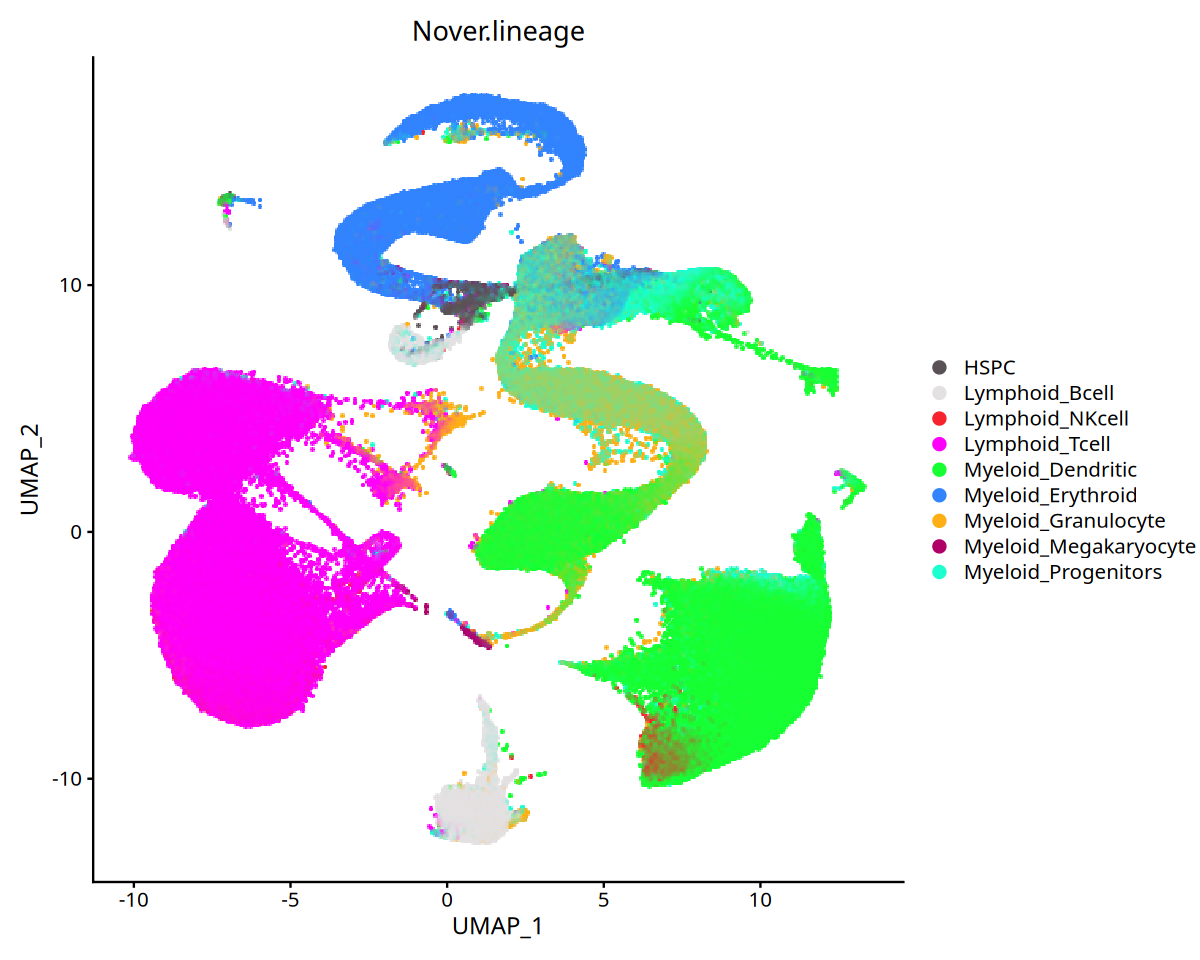

In [6]:
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1_TME, pt.size=2,reduction = "UMAP", group.by = c("Nover.lineage"),label=F,order=F) 

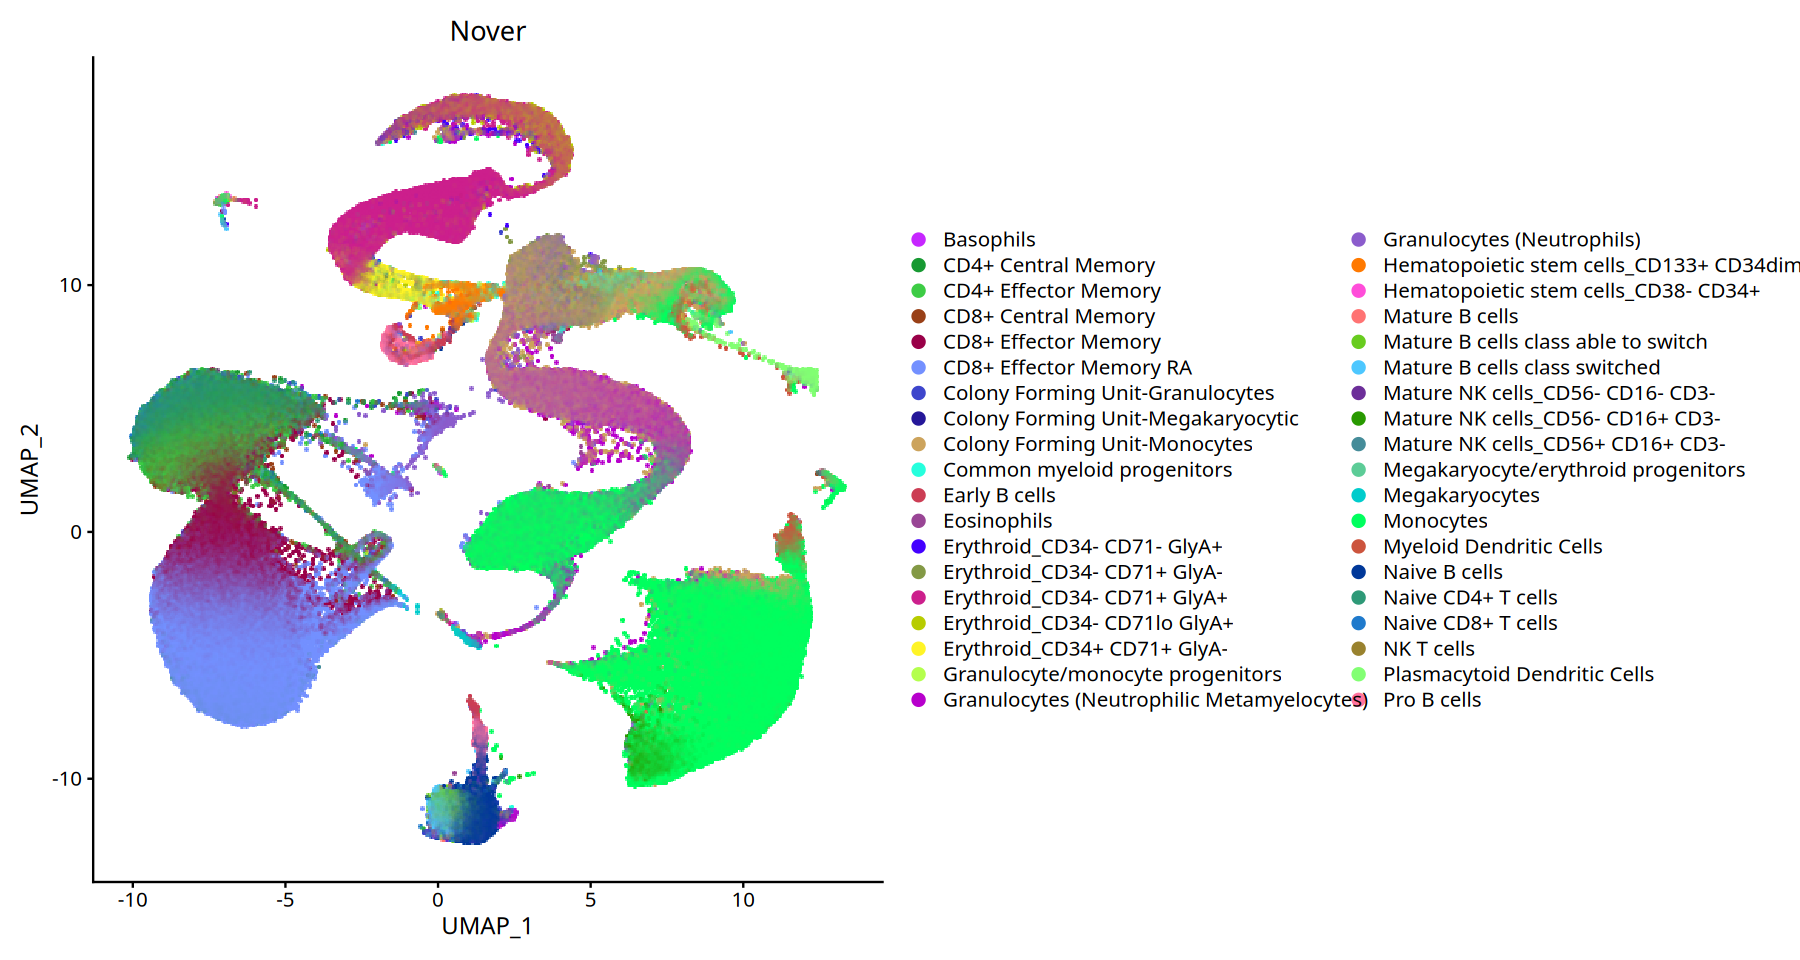

In [7]:
options(repr.plot.height=8,repr.plot.width=15)
DimPlot_scCustom(sce1_TME, pt.size=2,reduction = "UMAP", group.by = c("Nover"),label=F,order=F) 

In [8]:
p <- DimPlot_scCustom(sce1_TME, pt.size=2,reduction = "UMAP", group.by = c("Nover"),label=F,order=F) 
ggsave("Figs9a.pdf", plot = p, width = 15, height =8)


## 3. Visualization and figure generation


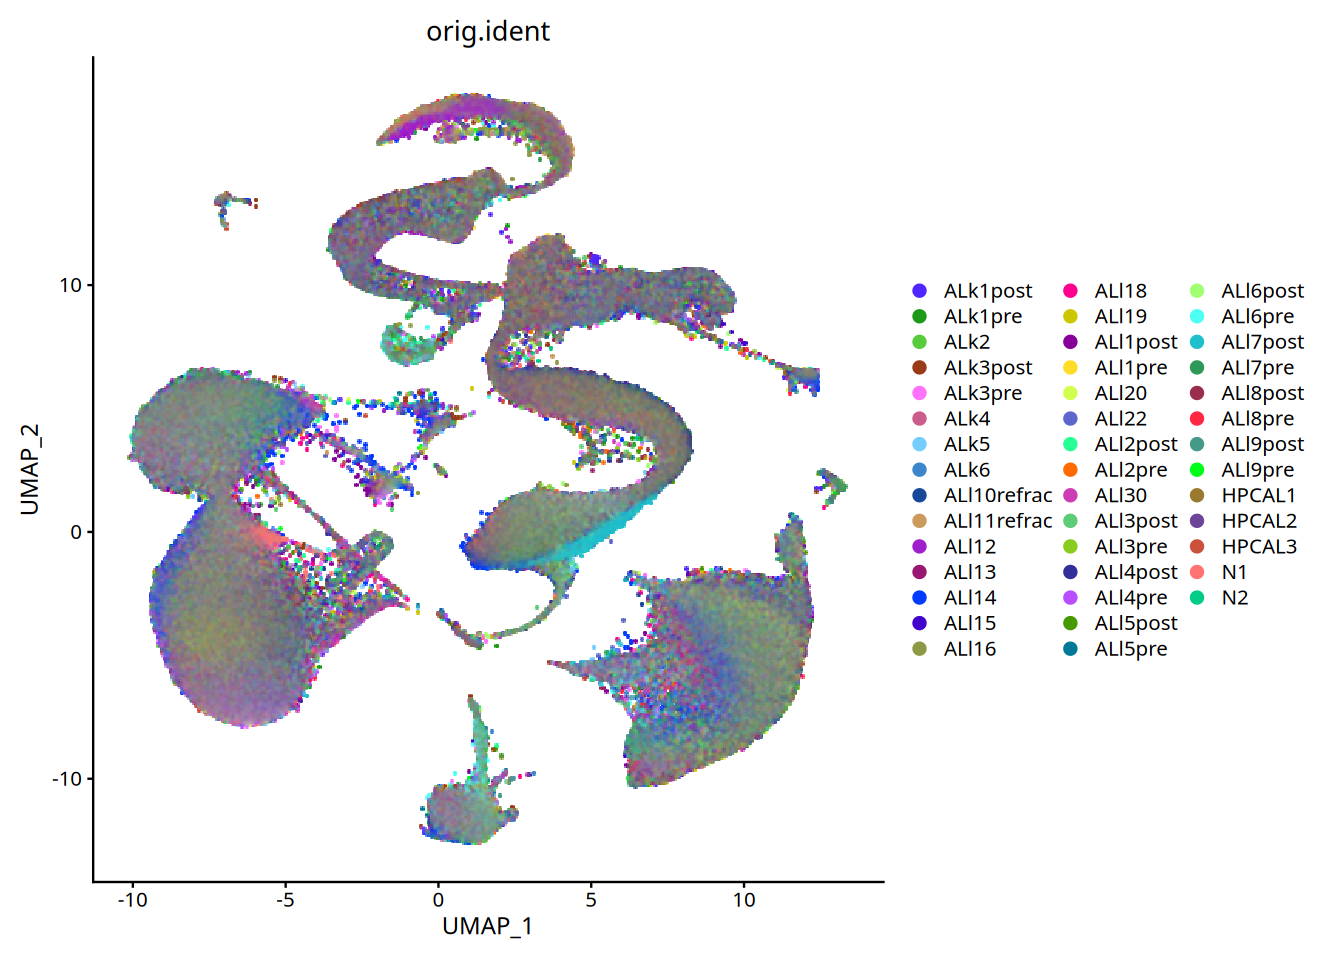

In [9]:
options(repr.plot.height=8,repr.plot.width=11)
DimPlot_scCustom(sce1_TME, pt.size=2,reduction = "UMAP", group.by = c("orig.ident"),label=F,order=F) 

In [10]:
p <- DimPlot_scCustom(sce1_TME, pt.size=2,reduction = "UMAP", group.by = c("orig.ident"),label=F,order=F) 
ggsave("Figs9b.pdf", plot = p, width = 11, height =8)


In [11]:
samplecelltype<-sce1_TME@meta.data[,c('orig.ident','Nover')]

In [12]:
# Generate the UMAP plot with DimPlot_scCustom
umap_plot <- DimPlot_scCustom(sce1_TME, pt.size=2,reduction = "UMAP", group.by = c("Nover"),label=F) 

# Extract the ggplot object
plot_data <- ggplot_build(umap_plot)

# Extract color mapping
color_mapping <- unique(plot_data$data[[1]]$colour)  # Unique colors

# Extract numeric cluster indices
numeric_indices <- unique(plot_data$data[[1]]$group)

# Map numeric indices to cluster names from Seurat object
Idents(sce1_TME)<-'Nover'
cluster_ids <- as.character(Idents(sce1_TME))  # Extract cluster names from Seurat object
numeric_to_name <- setNames(cluster_ids, as.numeric(factor(cluster_ids)))

# Map the numeric indices to cluster names
cluster_names <- numeric_to_name[as.character(numeric_indices)]

# Combine cluster names and colors into a data frame
color_cluster_df <- data.frame(
  Cluster = cluster_names,
  Color = color_mapping
)
color_cluster_df<-color_cluster_df[order(color_cluster_df$Cluster),]


Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


`summarise()` has grouped output by 'orig.ident'. You can override using the
`.groups` argument.


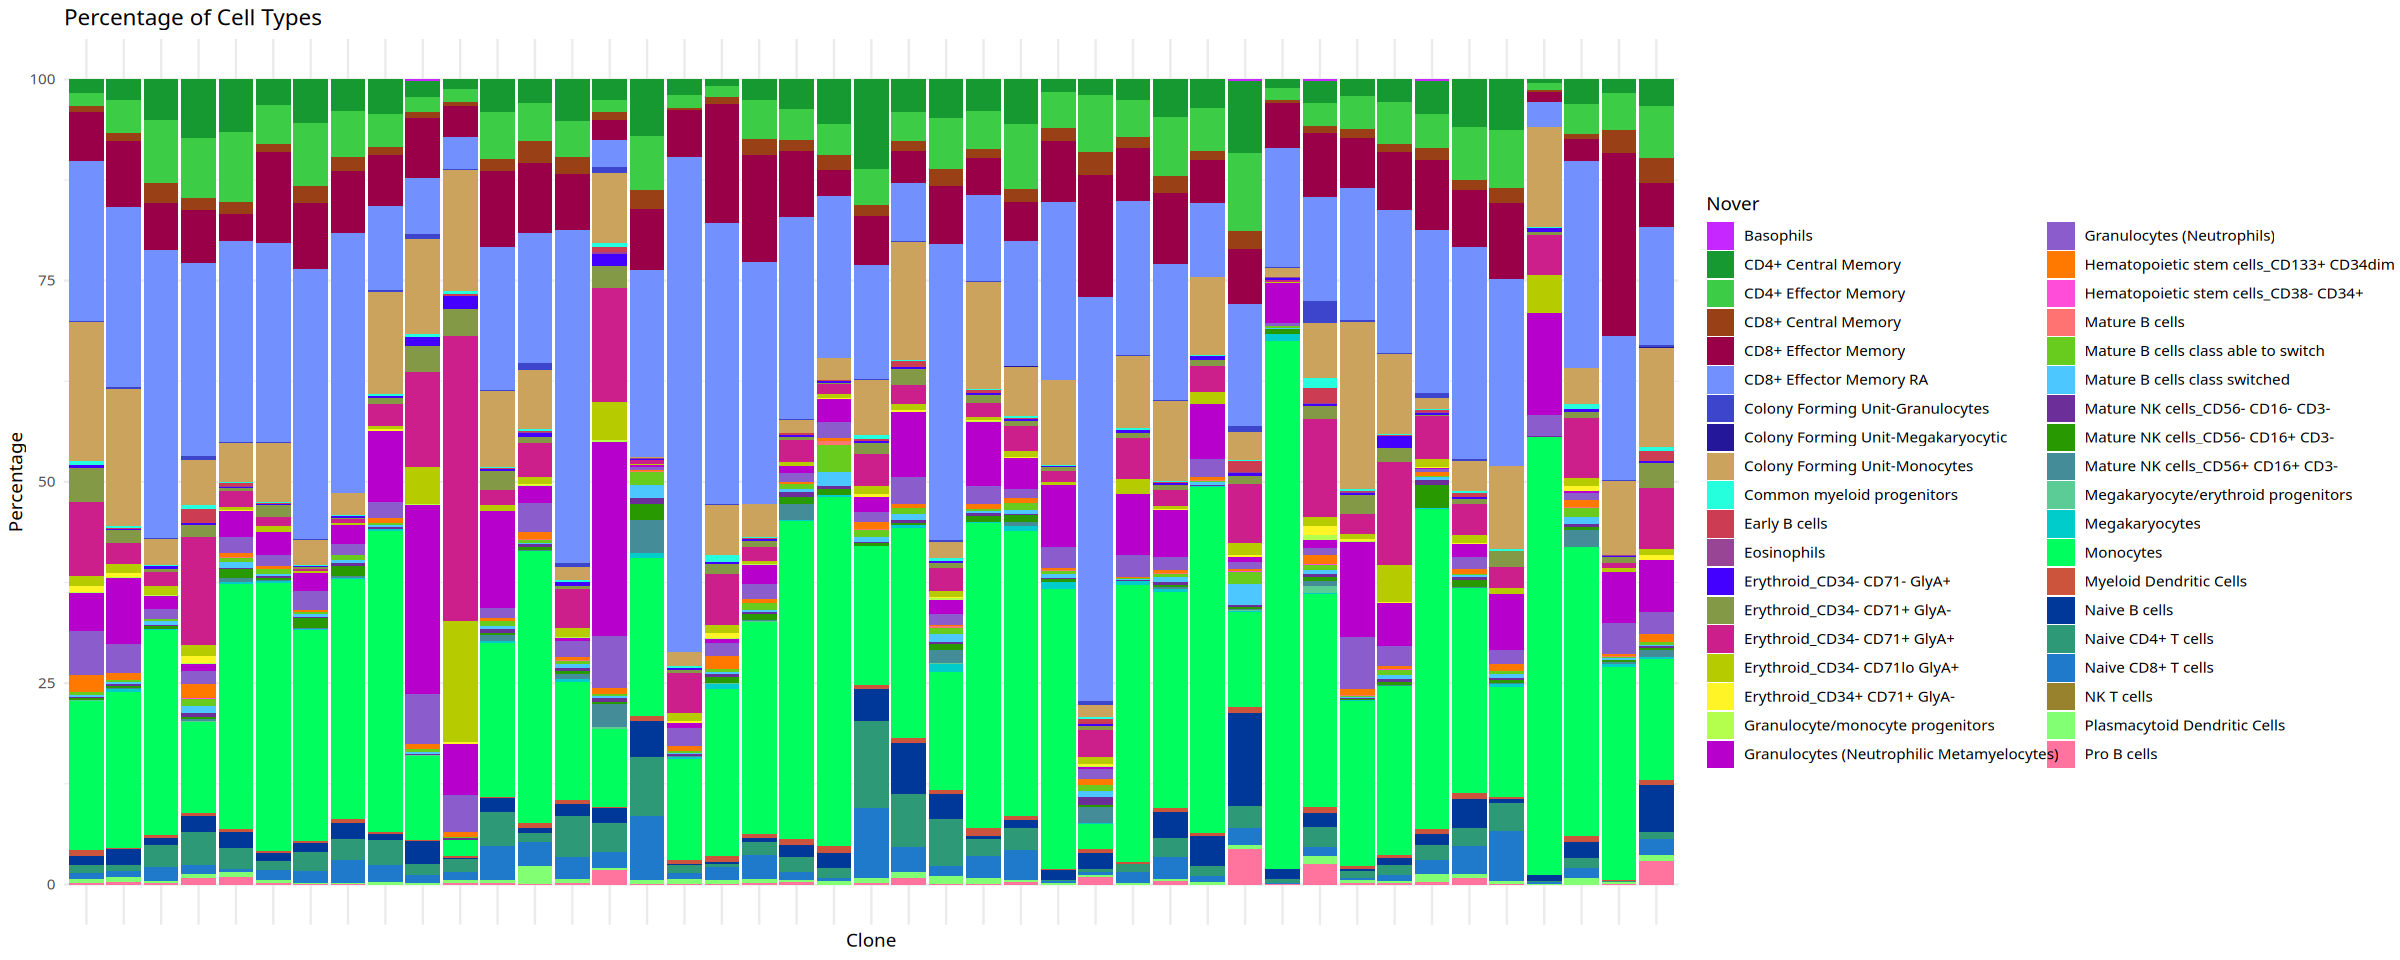

In [13]:
library(dplyr)
options(repr.plot.height=8,repr.plot.width=20)

# Step 2: Calculate the proportions
df_summary <- samplecelltype %>%
  group_by(orig.ident, Nover) %>%
  summarise(count = n()) %>%
  group_by(orig.ident) %>%
  mutate(percentage = count / sum(count) * 100)

# Step 3: Plot the stacked bar plot
ggplot(df_summary, aes(x = orig.ident, y = percentage, fill = Nover)) +
  geom_bar(stat = "identity") +
  labs(title = "Percentage of Cell Types",
       x = "Clone",
       y = "Percentage") +
  theme_minimal() +
scale_fill_manual(values = color_cluster_df$Color) + # Use a discrete color palette
theme(axis.text.x = element_blank(), # Remove x-axis text
        axis.ticks.x = element_blank()) # Remove x-axis ticks


## 4. Visualization and figure generation


In [14]:
library(reshape2)
library(ggplot2)
library(dendextend)
library("ggdendro")
samplecelltype_count<-as.data.frame(table(samplecelltype))
samplecelltype_count<-reshape(samplecelltype_count ,idvar = "Nover", timevar = "orig.ident", direction = "wide")
rownames(samplecelltype_count)<-samplecelltype_count$Nover
samplecelltype_count$Nover<-NULL
#Step 1: Perform hierarchical clustering on your data
# Assuming `filtered_samplecelltype_count` is your original data (wide format)
distance_matrix <- dist(t(samplecelltype_count))  # Compute distance between columns
hclust_result <- hclust(distance_matrix, method = "ward.D2")  # Hierarchical clustering
dendrogram <- as.dendrogram(hclust_result)

# Step 2: Reorder the data based on clustering order
cluster_order <- order.dendrogram(dendrogram)
samplecelltype_count_ordered <- samplecelltype_count[, cluster_order]


---------------------
Welcome to dendextend version 1.18.1
Type citation('dendextend') for how to cite the package.

Type browseVignettes(package = 'dendextend') for the package vignette.
The github page is: https://github.com/talgalili/dendextend/

Suggestions and bug-reports can be submitted at: https://github.com/talgalili/dendextend/issues
You may ask questions at stackoverflow, use the r and dendextend tags: 
	 https://stackoverflow.com/questions/tagged/dendextend

	To suppress this message use:  suppressPackageStartupMessages(library(dendextend))
---------------------



Attaching package: ‘dendextend’


The following object is masked from ‘package:stats’:

    cutree



Attaching package: ‘ggdendro’


The following object is masked from ‘package:dendextend’:

    theme_dendro




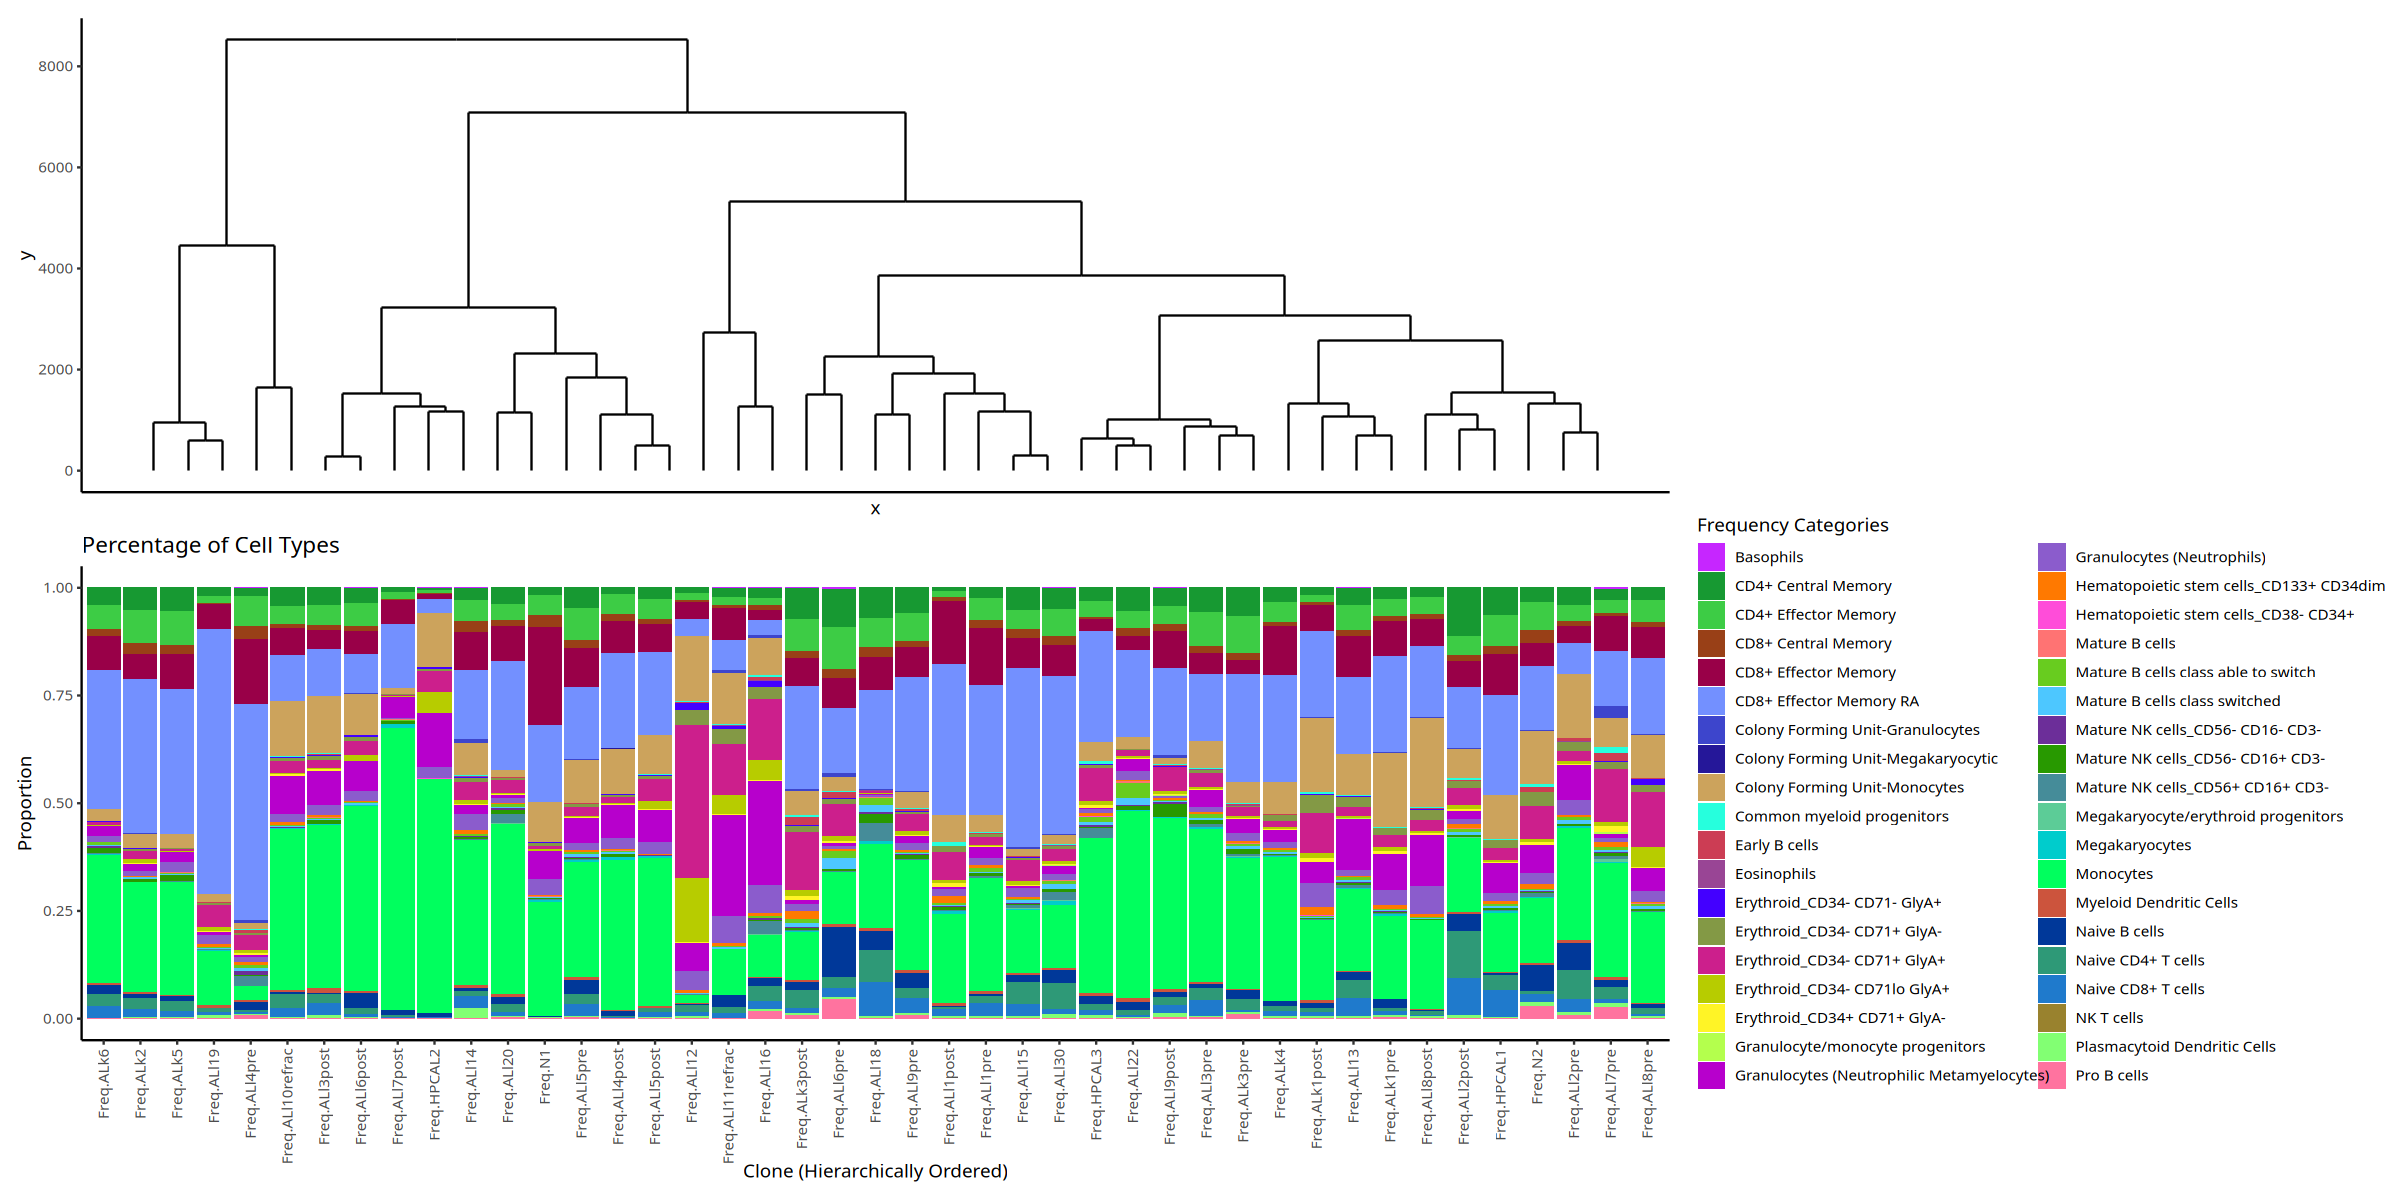

In [15]:
options(repr.plot.height=10,repr.plot.width=20)
# Convert to long format
samplecelltype_count_ordered$celltype<-rownames(samplecelltype_count_ordered)
data_long <- melt(samplecelltype_count_ordered, id.vars = "celltype")

# Step 3: Plot dendrogram
dendrogram_plot <- ggdendrogram(dendrogram, rotate = FALSE) +
  theme_classic() +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank())


# Step 4: Create the stacked bar plot
stacked_bar_plot <- ggplot(data_long, aes(fill = celltype, y = value, x = variable)) +
  geom_bar(position = "fill", stat = "identity") +
  labs(title = "Percentage of Cell Types",
       x = "Clone (Hierarchically Ordered)",
       y = "Proportion",
       fill = "Frequency Categories") +
  scale_fill_manual(values = color_cluster_df$Color) +  # Use your defined colors
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = .5))

# Step 5: Combine dendrogram and bar plot
library(patchwork)
combined_plot <- dendrogram_plot / stacked_bar_plot

# Display the combined plot
print(combined_plot)



Attaching package: ‘tidyr’


The following object is masked from ‘package:reshape2’:

    smiths


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


The following object is masked from ‘package:S4Vectors’:

    expand




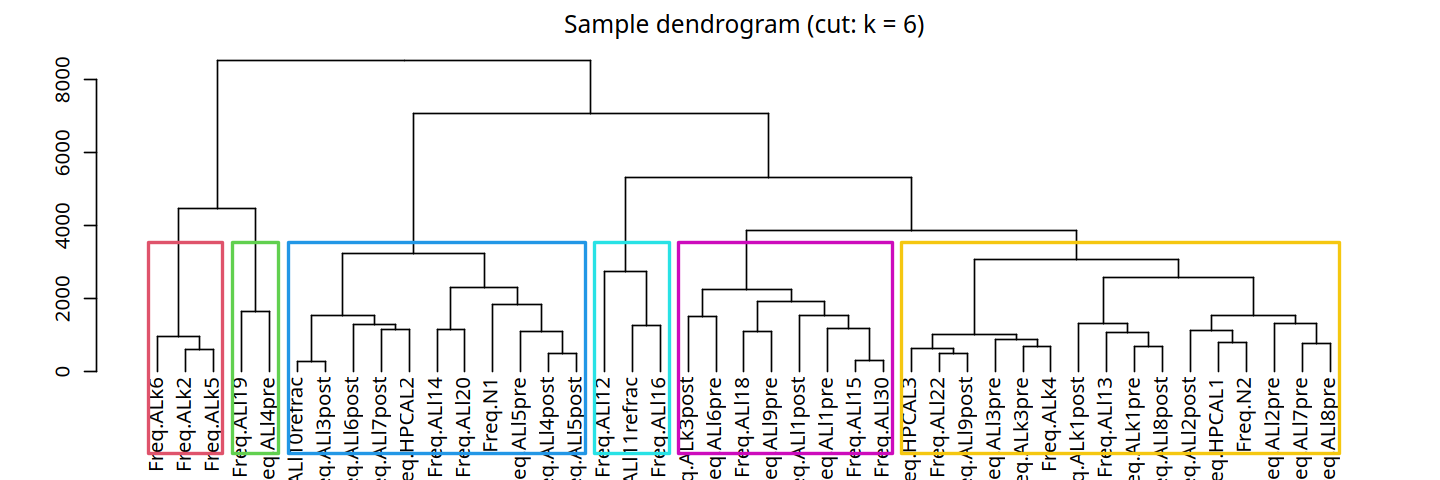

In [16]:
# --- Prereqs from your workflow (already created earlier) ---
# samplecelltype_count : rows = cell types (Nover), cols = samples (orig.ident), values = counts
# hclust_result        : created from `dist(t(samplecelltype_count))` and `hclust(..., method="ward.D2")`
# dendrogram           : as.dendrogram(hclust_result)
# color_cluster_df     : data.frame with Cluster (celltype) and Color
options(repr.plot.height=4,repr.plot.width=12)
library(dplyr)
library(tidyr)
library(ggplot2)
library(dendextend)
library(ggdendro)
library(patchwork)

# ====================== CONFIG ======================
k_groups <- 6        # <- choose one: number of groups ...
h_cut    <- NULL     # <- ... OR a height. If you set this (numeric), set k_groups <- NULL

# ====================== GUARANTEE SAME TREE / ORDER ======================
# Use exactly the same hclust_result used in your original plot:
stopifnot(inherits(hclust_result, "hclust"))
dendrogram <- as.dendrogram(hclust_result)

# This is the left->right sample order in the drawn dendrogram:
sample_order <- labels(dendrogram)

# ====================== CUT THE SAME TREE ======================
if (!is.null(k_groups)) {
  grp <- cutree(hclust_result, k = k_groups)
  cut_info <- paste0("k = ", k_groups)
  # For display, compute the implied cut height (min branch height separating clusters)
  # (purely informational; drawing rectangles is clearer for k).
  h_display <- NULL
} else if (!is.null(h_cut)) {
  grp <- cutree(hclust_result, h = h_cut)
  cut_info <- paste0("h = ", h_cut)
  h_display <- h_cut
} else {
  stop("Set either k_groups or h_cut.")
}

# Keep a tidy frame of groups in the SAME order as dendrogram leaves
grp_df <- data.frame(sample = names(grp), group = grp, stringsAsFactors = FALSE) %>%
  mutate(sample = factor(sample, levels = sample_order)) %>%
  arrange(sample)

# ====================== DENDROGRAM WITH CUT (BASE R) ======================
# This guarantees what you see is exactly the cut applied.
# - If k_groups is set: rectangles highlight the clusters
# - If h_cut is set: a horizontal line shows the height threshold
op <- par(no.readonly = TRUE)
par(mar = c(4, 4, 2, 2))
plot(dendrogram, main = paste0("Sample dendrogram (cut: ", cut_info, ")"))
if (!is.null(k_groups)) {
  rect.dendrogram(dendrogram, k = k_groups, border = 2:(k_groups + 1), lwd = 2)
}
if (!is.null(h_cut)) {
  abline(h = h_cut, lty = 2, lwd = 2)
}
par(op)

# ====================== OPTIONAL: GGPlot Dendrogram with Cut Line ======================
# (Nice for combining with your stacked bars)
# Color branches by group membership to visually match the cut
dend_col <- color_branches(dendrogram, k = length(unique(grp)))
# Convert to ggplot-friendly data
dd <- ggdendro::dendro_data(dend_col, type = "rectangle")

dendrogram_plot <- ggplot() +
  geom_segment(data = dd$segments,
               aes(x = x, y = y, xend = xend, yend = yend),
               linewidth = 0.4) +
  theme_classic() +
  labs(title = paste0("Sample dendrogram (cut: ", cut_info, ")"),
       x = NULL, y = "Height") +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        plot.margin = margin(t = 5, r = 5, b = 5, l = 5))

if (!is.null(h_display)) {
  dendrogram_plot <- dendrogram_plot +
    geom_hline(yintercept = h_display, linetype = "dashed", linewidth = 0.6)
}

# ====================== AVERAGE COMPOSITION PER GROUP (SAME CUT) ======================
# Convert counts to per-sample proportions
samplecelltype_count[is.na(samplecelltype_count)] <- 0
prop_mat <- sweep(samplecelltype_count, 2, pmax(colSums(samplecelltype_count), 1e-12), "/")

# Average columns within each group
group_levels <- unique(grp_df$group)   # keep numeric order of groups
avg_mat <- sapply(group_levels, function(g) {
  s <- grp_df$sample[grp_df$group == g] |> as.character()
  if (length(s) == 1) {
    prop_mat[, s, drop = FALSE]
  } else {
    rowMeans(prop_mat[, s, drop = FALSE])
  }
})
# Ensure matrix (if k=1 or shape edge cases)
avg_mat <- as.matrix(avg_mat)
colnames(avg_mat) <- paste0("Group_", group_levels)

# Long DF for stacked bar
avg_long <- as.data.frame(avg_mat) |>
  mutate(celltype = rownames(avg_mat)) |>
  pivot_longer(starts_with("Group_"), names_to = "group", values_to = "proportion")

# Colors (use your mapping; fall back to defaults if missing)
ct_colors <- setNames(color_cluster_df$Color, color_cluster_df$Cluster)
present_ct <- intersect(names(ct_colors), unique(avg_long$celltype))
ct_colors_use <- ct_colors[present_ct]

stacked_bar_plot <- ggplot(avg_long, aes(x = group, y = proportion, fill = celltype)) +
  geom_bar(stat = "identity", position = "fill") +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  scale_fill_manual(values = ct_colors_use, breaks = names(ct_colors_use)) +
  labs(title = "Average Cell-Type Composition per Dendrogram Group",
       x = "Groups from the SAME dendrogram cut",
       y = "Proportion", fill = "Cell type") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0.5),
        legend.position = "right",
        plot.margin = margin(t = 5, r = 5, b = 5, l = 5))



## 5. Stacked_bar_plot


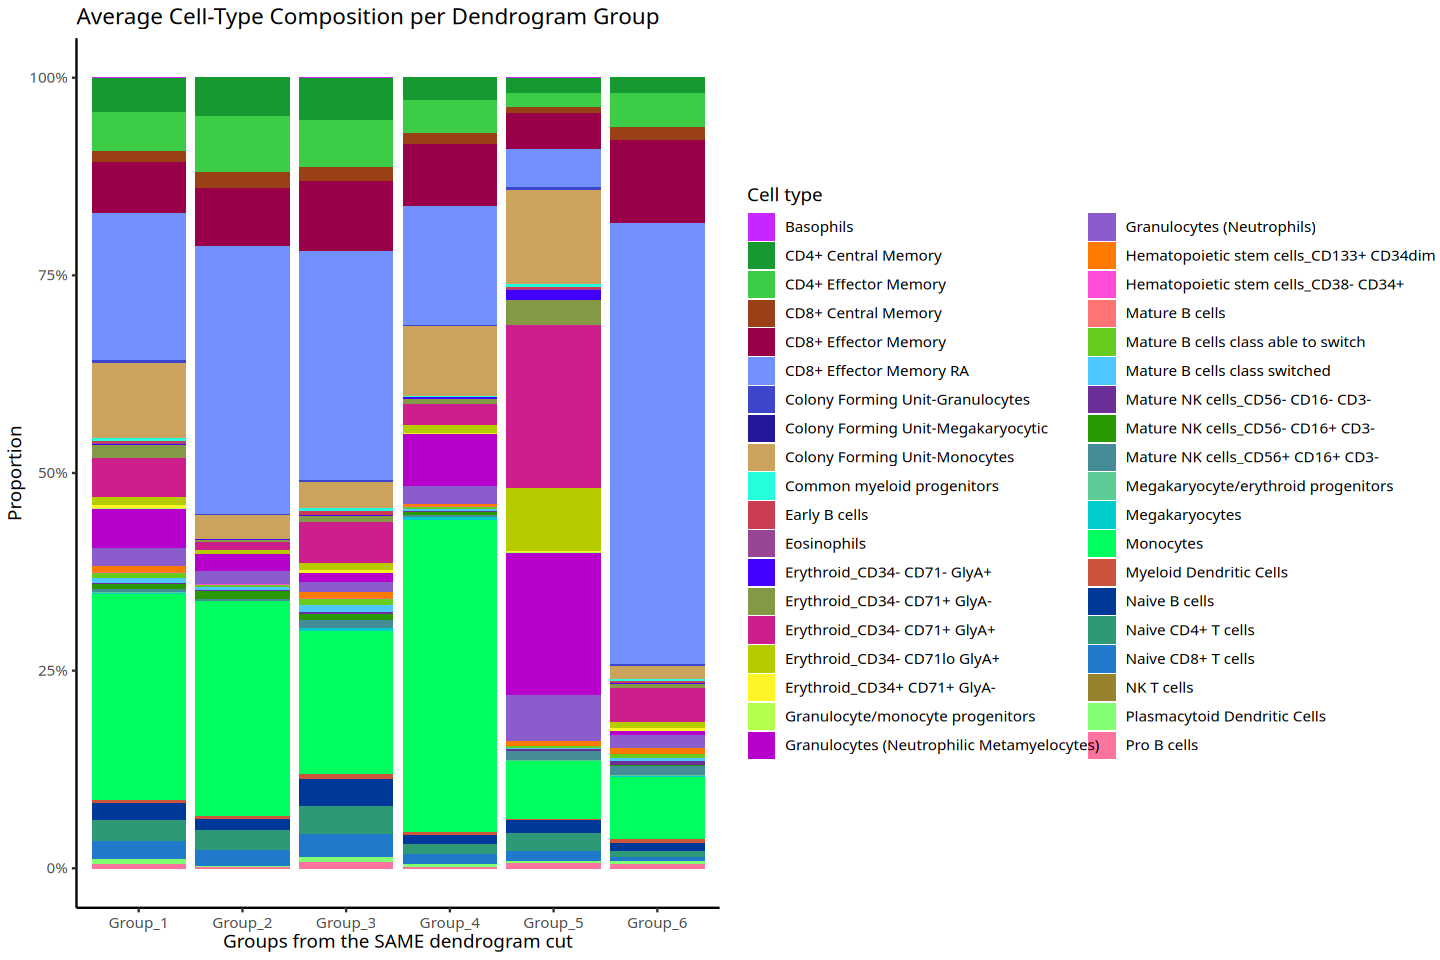

In [17]:
options(repr.plot.height=8,repr.plot.width=12)
stacked_bar_plot

In [18]:
label<-sce1_TME@meta.data
label$barcode<-rownames(label)
label<-label[,c('barcode','Nover')]
write.csv(label,file='TME.noverlabel.csv')

In [19]:
# Generate the UMAP plot with DimPlot_scCustom
umap_plot <- DimPlot_scCustom(sce1_TME, pt.size=2,reduction = "UMAP", group.by = c("Nover"),label=F) 

# Extract the ggplot object
plot_data <- ggplot_build(umap_plot)

# Extract color mapping
color_mapping <- unique(plot_data$data[[1]]$colour)  # Unique colors

# Extract numeric cluster indices
numeric_indices <- unique(plot_data$data[[1]]$group)

# Map numeric indices to cluster names from Seurat object
Idents(sce1_TME)<-'Nover'
cluster_ids <- as.character(Idents(sce1_TME))  # Extract cluster names from Seurat object
numeric_to_name <- setNames(cluster_ids, as.numeric(factor(cluster_ids)))

# Map the numeric indices to cluster names
cluster_names <- numeric_to_name[as.character(numeric_indices)]

# Combine cluster names and colors into a data frame
color_cluster_df <- data.frame(
  Cluster = cluster_names,
  Color = color_mapping
)
color_cluster_df<-color_cluster_df[order(color_cluster_df$Cluster),]
rownames(color_cluster_df)<-color_cluster_df$Cluster

In [20]:
#T cells

In [21]:
sce1_tcell <- subset(sce1_TME, Nover.lineage %in% "Lymphoid_Tcell")

## 6. Normalization, integration, and dimensional reduction


In [22]:
sce1_tcell

An object of class Seurat 
36601 features across 147227 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, UMAP

In [23]:
# Step 3: Proceed with PCA and UMAP
sce1_tcell <- ScaleData(sce1_tcell, features = VariableFeatures(sce1_tcell))
sce1_tcell <- RunPCA(sce1_tcell, features = VariableFeatures(sce1_tcell))

Centering and scaling data matrix

Warning message:
“The following 65 features requested have zero variance; running reduction without them: IGHA1, HBM, AREG, NRGN, FN1, TRBV7-6, TRBV10-3, HIST1H1D, BGN, CDC20, IGHV3-74, LILRA4, S100B, HIST1H3D, IGHV3-53, IGLV10-54, IGHV1-46, IGKV1OR22-5, PRKAR2B, STMN2, IGHV3-69-1, RNASE2, CLEC3B, PAPPA, SLPI, TRAV12-3, CPOX, AP003068.2, ABCC3, C19orf48, MCM6, GZMB, PBK, NPR3, CALR, AC245060.5, HTRA2, AC114752.2, CD82, TAC3, SLIRP, AQP3, GPR88, RIF1, FADS2, AC128707.1, AC103876.1, EMP2, MYCT1, FOSB, TMPO, TRGC2, MEOX2, AL592182.3, SULF1, VTN, AVPR1A, EGLN3, PCAT18, CYC1, WRN, SNHG25, MEF2C, LINC00640, SLC7A10”
PC_ 1 
Positive:  CCL5, GZMA, GZMH, FGFBP2, KLRD1, GNLY, CCL4, HLA-DRB1, HLA-DPB1, FCGR3A 
	   SRGN, LGALS1, PCLAF, HLA-DPA1, MKI67, TYMS, SPON2, HLA-DRA, RRM2, CLIC3 
	   CD74, NUSAP1, KLRF1, TOP2A, BIRC5, CLSPN, HLA-DRB5, TK1, TRDC, TPX2 
Negative:  LTB, IL7R, MAL, EEF1B2, CCR7, LEF1, SNHG29, LDHB, RPL23, CD27 
	   GPR183, RPLP0, SOCS3, MYC, N

In [24]:
sce1_tcell <- FindNeighbors(sce1_tcell, dims = 1:15, reduction = "pca")
sce1_tcell <- FindClusters(sce1_tcell, resolution =0.3, cluster.name = "seurat_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 147227
Number of edges: 3365949

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9042
Number of communities: 12
Elapsed time: 66 seconds


## 7. Normalization, integration, and dimensional reduction


In [25]:
sce1_tcell <- RunUMAP(sce1_tcell, dims = 1:15, reduction = "pca", reduction.name = "UMAP")

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
21:20:19 UMAP embedding parameters a = 0.9922 b = 1.112

21:20:19 Read 147227 rows and found 15 numeric columns

21:20:19 Using Annoy for neighbor search, n_neighbors = 30

21:20:19 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:20:35 Writing NN index file to temp file /tmp/RtmpNMQRfF/file745b320897c7

21:20:35 Searching Annoy index using 1 thread, search_k = 3000

21:21:46 Annoy recall = 100%

21:21:47 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors

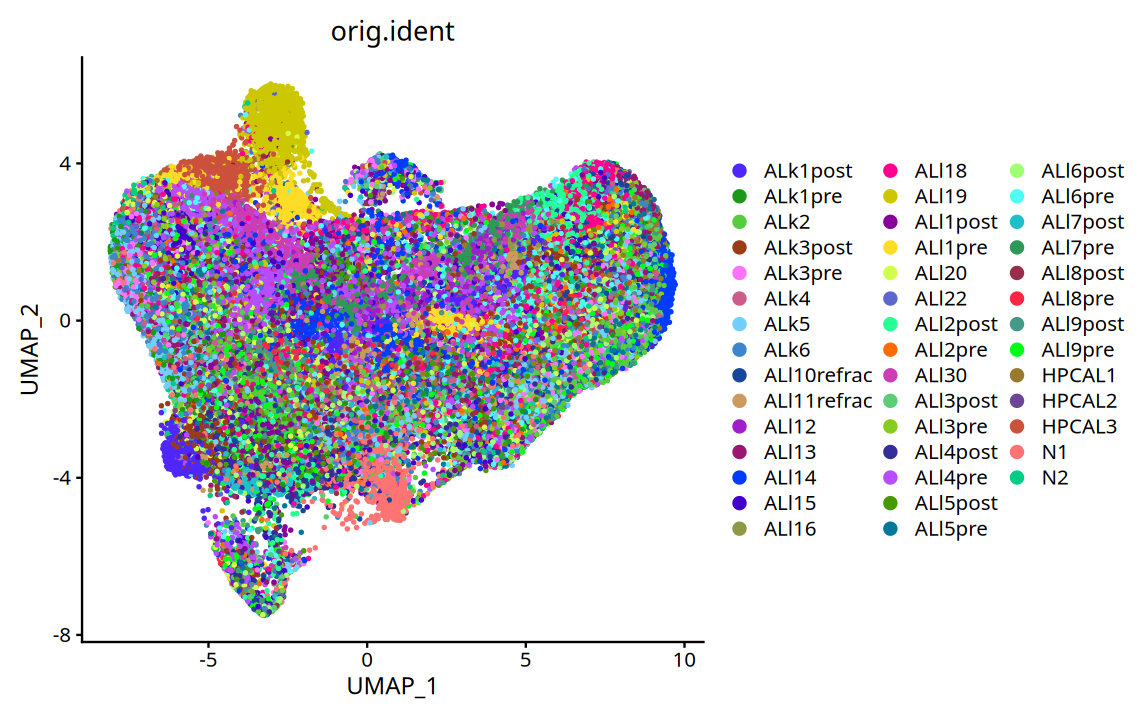

In [26]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_tcell, pt.size=0.5,reduction = "UMAP", group.by = c("orig.ident"),label=F) 

In [27]:
clusters_to_remove <- '5'
sce1_ALl19 <- subset(sce1_tcell, seurat_clusters %in% clusters_to_remove)
sce1_tcell <- subset(sce1_tcell, seurat_clusters %in% setdiff(0:11, clusters_to_remove))
write.csv(sce1_ALl19@meta.data,file='sce1_ALl19clustermeta.data.csv')

In [28]:
# Step 3: Proceed with PCA and UMAP
sce1_tcell <- ScaleData(sce1_tcell, features = VariableFeatures(sce1_tcell))
sce1_tcell <- RunPCA(sce1_tcell, features = VariableFeatures(sce1_tcell))

Centering and scaling data matrix

Warning message:
“The following 68 features requested have zero variance; running reduction without them: IGHA1, HBM, AREG, NRGN, FN1, TRBV7-6, TRBV10-3, HIST1H1D, BGN, CDC20, IGHV3-74, LILRA4, S100B, TRBV5-4, HIST1H3D, IGHV3-53, IGLV10-54, IGHV1-46, IGKV1OR22-5, PRKAR2B, STMN2, IGHV3-69-1, RNASE2, CLEC3B, PAPPA, TRDV1, SLPI, TRAV12-3, CPOX, AP003068.2, ABCC3, C19orf48, MCM6, GZMB, PBK, NPR3, RAG1, CALR, AC245060.5, HTRA2, AC114752.2, CD82, TAC3, SLIRP, AQP3, GPR88, RIF1, FADS2, AC128707.1, AC103876.1, EMP2, MYCT1, FOSB, TMPO, TRGC2, MEOX2, AL592182.3, SULF1, VTN, AVPR1A, EGLN3, PCAT18, CYC1, WRN, SNHG25, MEF2C, LINC00640, SLC7A10”
PC_ 1 
Positive:  GZMA, CCL5, GZMH, FGFBP2, KLRD1, GNLY, CCL4, HLA-DRB1, HLA-DPB1, PCLAF 
	   TYMS, MKI67, FCGR3A, SRGN, LGALS1, HLA-DPA1, RRM2, HLA-DRA, NUSAP1, SPON2 
	   CD74, CLIC3, KLRF1, BIRC5, TOP2A, CLSPN, TK1, HLA-DRB5, TPX2, TRDC 
Negative:  LTB, IL7R, EEF1B2, MAL, CCR7, LEF1, SNHG29, RPL23, LDHB, CD27 
	   RPLP0,

In [29]:
sce1_tcell <- FindNeighbors(sce1_tcell, dims = 1:15, reduction = "pca")
sce1_tcell <- FindClusters(sce1_tcell, resolution =0.3, cluster.name = "seurat_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 142591
Number of edges: 3268814

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9015
Number of communities: 11
Elapsed time: 60 seconds


## 8. Normalization, integration, and dimensional reduction


In [30]:
sce1_tcell <- RunUMAP(sce1_tcell, dims = 1:15, reduction = "pca", reduction.name = "UMAP")

21:26:42 UMAP embedding parameters a = 0.9922 b = 1.112

21:26:42 Read 142591 rows and found 15 numeric columns

21:26:42 Using Annoy for neighbor search, n_neighbors = 30

21:26:42 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:26:58 Writing NN index file to temp file /tmp/RtmpNMQRfF/file745b7a3b723c

21:26:58 Searching Annoy index using 1 thread, search_k = 3000

21:28:04 Annoy recall = 100%

21:28:05 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

21:28:11 Initializing from normalized Laplacian + noise (using RSpectra)

21:28:16 Commencing optimization for 200 epochs, with 6180214 positive edges

21:28:16 Using rng type: pcg

21:29:48 Optimization finished



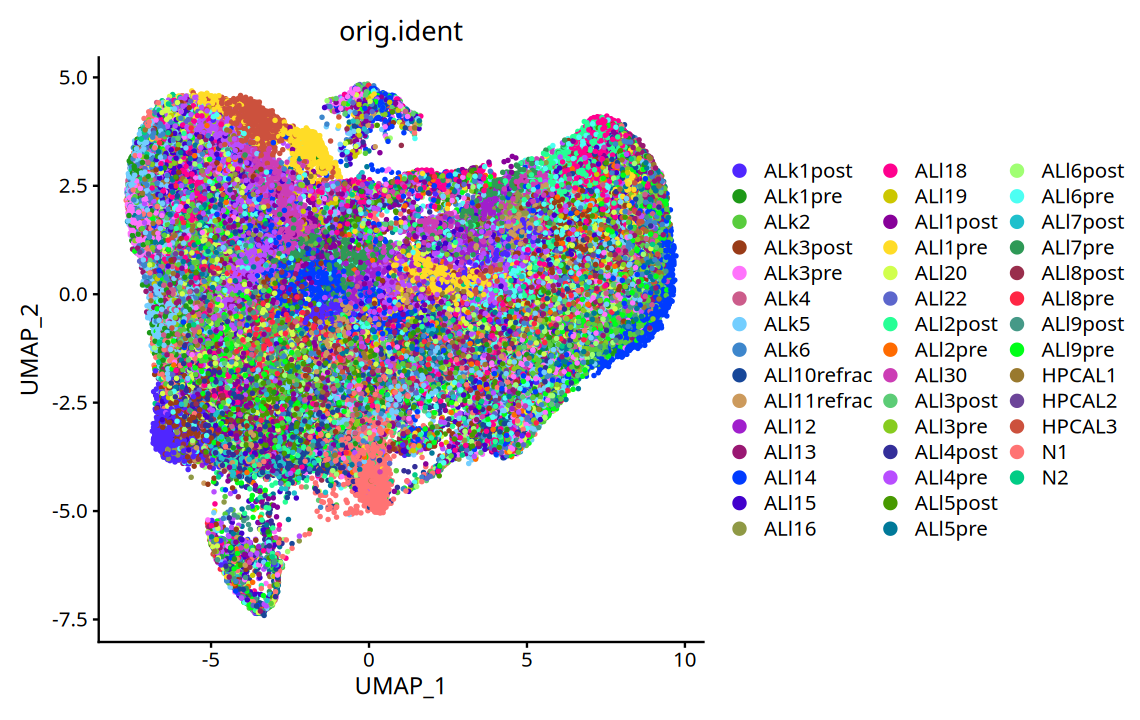

In [31]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_tcell, pt.size=0.5,reduction = "UMAP", group.by = c("orig.ident"),label=F) 

In [32]:
library(harmony)
obj<-sce1_tcell
obj <- RunHarmony(obj, "orig.ident")
obj <- RunUMAP(obj, reduction = "harmony",dims=1:30)
obj <- FindNeighbors(obj, dims = 1:30, reduction = "harmony")
obj <- FindClusters(obj, resolution = 0.2, cluster.name = "harmony_clusters")

Loading required package: Rcpp

Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7129550)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7129550)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7129550)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7129550)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7129550)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7129550)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7129550)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

21:33:25 UMAP embedding parameters a = 0.9922 b = 1.112

21:33:25 Read 142591 rows and found 30 numeric columns

21:33:25 Using Annoy for neighbor search, n_neighbors = 30

21:33:25 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 142591
Number of edges: 2755965

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9345
Number of communities: 54
Elapsed time: 40 seconds


41 singletons identified. 13 final clusters.



## 9. Normalization, integration, and dimensional reduction


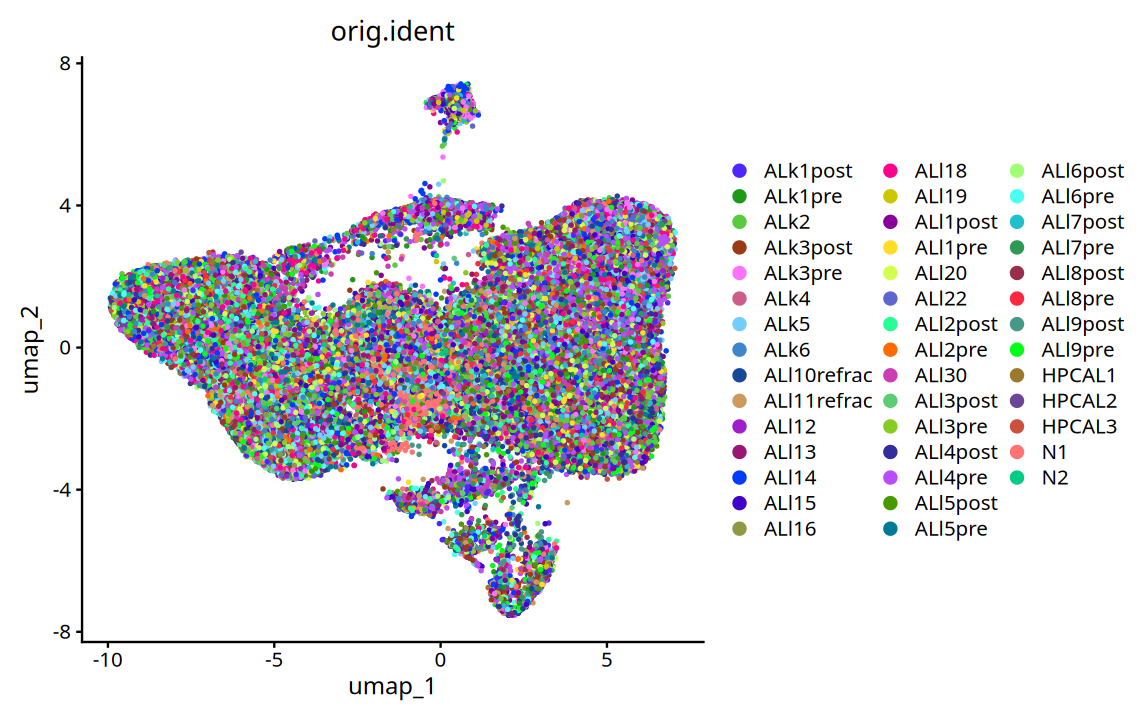

In [33]:
library(scCustomize)
sce1_tcell<-obj
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_tcell, pt.size=0.5,reduction = "umap", group.by = c("orig.ident"),label=F) 

#STARCAT scores

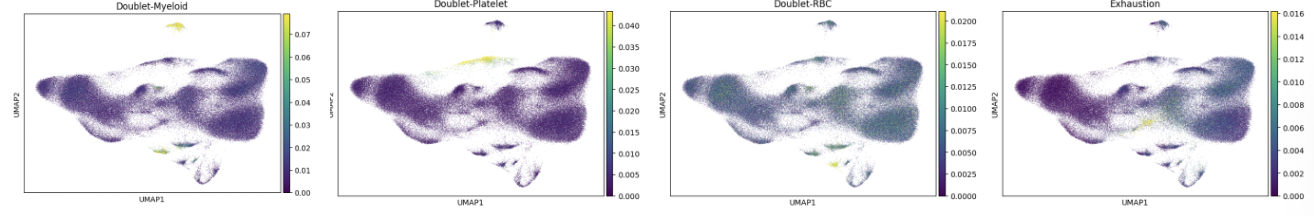

In [34]:
sce1_tcell <- subset(sce1_tcell, idents = c('7',"8","10",'11','7','12'), invert = TRUE)

In [35]:
library(harmony)
obj<-sce1_tcell
obj <- RunUMAP(obj, reduction = "harmony",dims=1:30)
obj <- FindNeighbors(obj, dims = 1:30, reduction = "harmony")
obj <- FindClusters(obj, resolution = 0.2, cluster.name = "harmony_clusters")

21:38:48 UMAP embedding parameters a = 0.9922 b = 1.112

21:38:48 Read 135109 rows and found 30 numeric columns

21:38:48 Using Annoy for neighbor search, n_neighbors = 30

21:38:48 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:39:03 Writing NN index file to temp file /tmp/RtmpNMQRfF/file745b6d0dab48

21:39:03 Searching Annoy index using 1 thread, search_k = 3000

21:40:07 Annoy recall = 100%

21:40:08 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

21:40:14 Initializing from normalized Laplacian + noise (using RSpectra)

21:40:20 Commencing optimization for 200 epochs, with 6345244 positive edges

21:40:20 Using rng type: pcg

21:41:49 Optimization finished

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 135109
Number of edges: 2490800

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9239
Number of communities: 32
Elapsed time: 35 seconds


24 singletons identified. 8 final clusters.



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



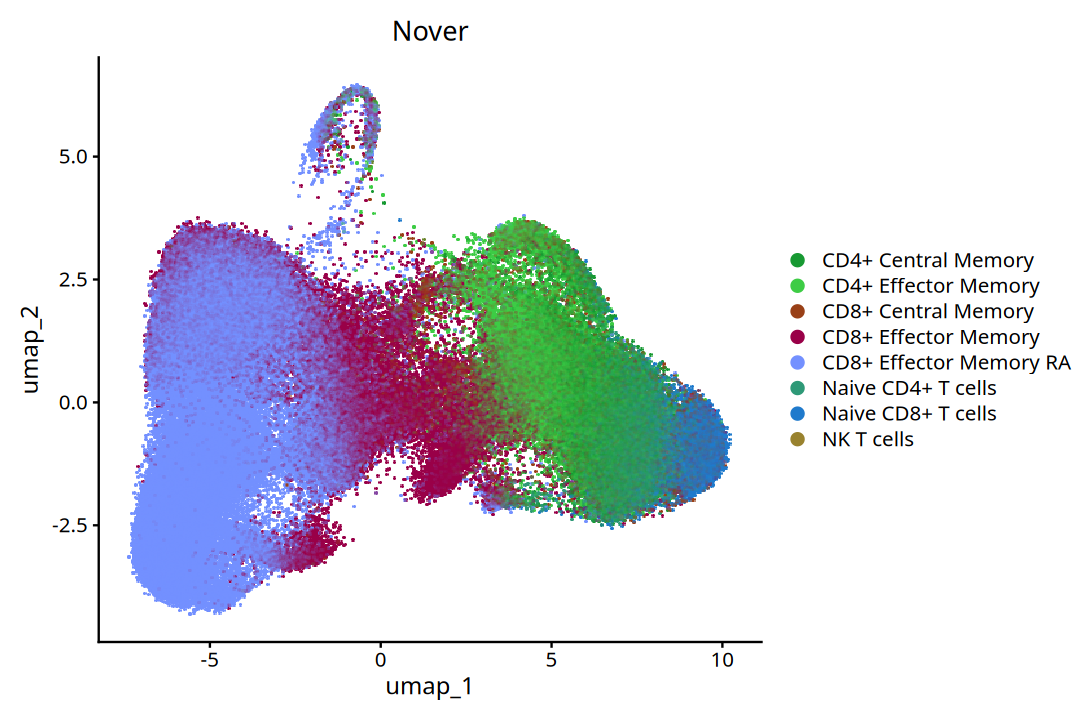

In [36]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9)
sce1_tcell<-obj
celltypes<-sort(unique(sce1_tcell@meta.data$Nover))
DimPlot(sce1_tcell, pt.size=2,reduction = "umap", group.by = c("Nover"),label=F,cols=color_cluster_df[celltypes,]$Color) 

In [37]:
sce1_tcell

An object of class Seurat 
36601 features across 135109 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, UMAP, harmony, umap

## 10. Save and export results


In [38]:
saveRDS(sce1_tcell, file = "sce1_Tcell.rds")

In [39]:
#B cells

In [40]:
sce1_bcell <- subset(sce1_TME, Nover.lineage %in% "Lymphoid_Bcell")

## 11. Normalization, integration, and dimensional reduction


In [41]:
sce1_bcell

An object of class Seurat 
36601 features across 12463 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, UMAP

In [42]:
# Step 3: Proceed with PCA and UMAP
sce1_bcell <- ScaleData(sce1_bcell, features = VariableFeatures(sce1_bcell))
sce1_bcell <- RunPCA(sce1_bcell, features = VariableFeatures(sce1_bcell))

Centering and scaling data matrix

Warning message:
“The following 188 features requested have zero variance; running reduction without them: IGLV2-14, IGLL1, IGHA1, GP1BB, HBM, DEFA4, HIST1H4C, AHSP, TUBB1, IGHV1-18, HIST1H1B, OLFML3, TCL1A, IGHM, TRBV7-6, MYL4, TRBV10-3, TRBV11-1, STMN1, TRBV3-1, S100B, TRBV6-5, CPA3, CXCL13, H1F0, IGHV3-43, CLEC11A, TFPI, STMN2, IGHV3-69-1, IGHV3-15, GDF15, CD74, TRBV9, RNASE2, IFIT2, CLEC3B, PAPPA, AKAP12, EBF1, S100A12, ADCY6, TDO2, TRBV6-7, C19orf33, C15orf48, GTSE1, APOC2, AP003068.2, TUBB2A, IGKV1-12, CD34, ABCC3, FST, MAP3K7CL, LGALS2, ENPP1, CENPM, COL6A3, C1QBP, MAD2L1, LGALSL, NUF2, TNFRSF11B, BAMBI, TRAV1-2, CYP26B1, PROK1, AURKB, XPO7, ISLR, MMD, SLC40A1, CEACAM8, PAX5, GUCY1B1, STAB2, FNDC1, NCL, AURKA, SLC29A1, ATP5MC1, BOLA3, PCAT14, DPT, TRDC, PROS1, C19orf48, GCSH, CENPH, TRAV10, CCL13, SPX, LINC00926, MCM6, C11orf87, GZMB, RPLP0, CLEC2L, IGHV3-64D, CAT, DTL, IL12B, CD1E, DKC1, TRDV3, ITGBL1, NCAM2, CALR, DUSP9, AC245060.5, HTRA2, FO

In [43]:
sce1_bcell <- FindNeighbors(sce1_bcell, dims = 1:15, reduction = "pca")
sce1_bcell <- FindClusters(sce1_bcell, resolution =0.3, cluster.name = "seurat_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12463
Number of edges: 388398

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9016
Number of communities: 8
Elapsed time: 1 seconds


In [44]:
sce1_bcell <- RunUMAP(sce1_bcell, dims = 1:15, reduction = "pca", reduction.name = "UMAP")

21:51:17 UMAP embedding parameters a = 0.9922 b = 1.112

21:51:17 Read 12463 rows and found 15 numeric columns

21:51:17 Using Annoy for neighbor search, n_neighbors = 30

21:51:17 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:51:18 Writing NN index file to temp file /tmp/RtmpNMQRfF/file745b6e851c26

21:51:18 Searching Annoy index using 1 thread, search_k = 3000

21:51:22 Annoy recall = 100%

21:51:23 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

21:51:25 Initializing from normalized Laplacian + noise (using RSpectra)

21:51:26 Commencing optimization for 200 epochs, with 517252 positive edges

21:51:26 Using rng type: pcg

21:51:33 Optimization finished



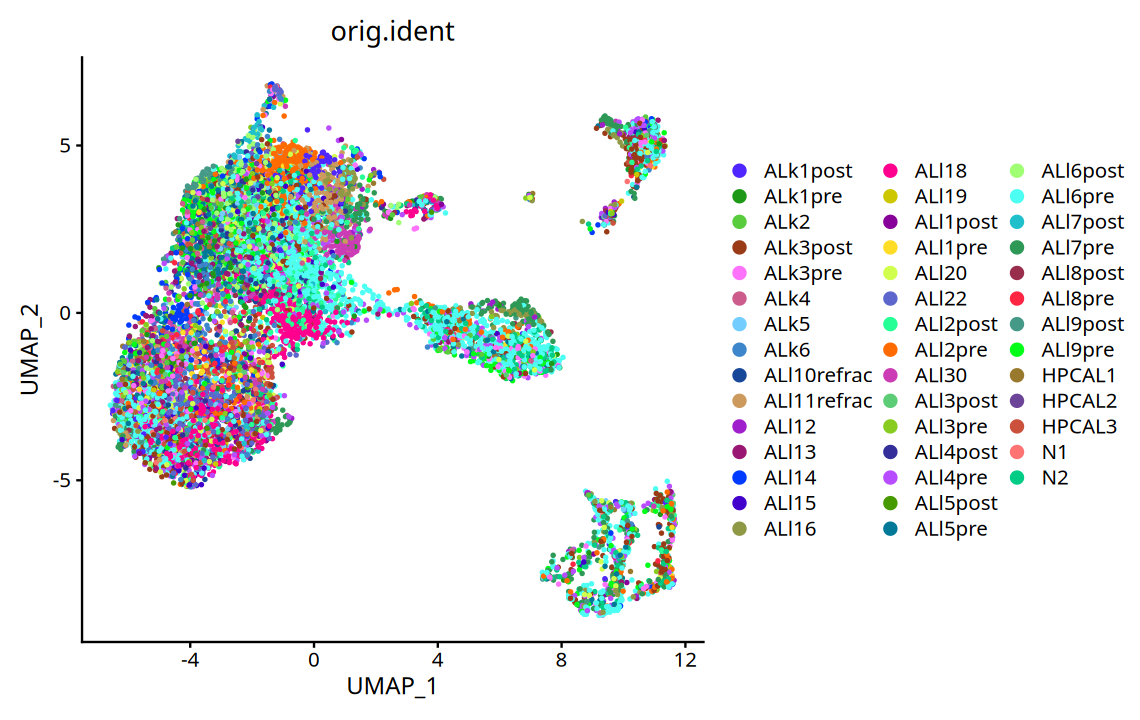

In [45]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_bcell, pt.size=0.5,reduction = "UMAP", group.by = c("orig.ident"),label=F) 

## 12. Normalization, integration, and dimensional reduction


In [46]:
library(harmony)
obj<-sce1_bcell
obj <- RunHarmony(obj, "orig.ident")
obj <- RunUMAP(obj, reduction = "harmony",dims=1:30)
obj <- FindNeighbors(obj, dims = 1:30, reduction = "harmony")
obj <- FindClusters(obj, resolution = 0.2, cluster.name = "harmony_clusters")

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

21:51:44 UMAP embedding parameters a = 0.9922 b = 1.112

21:51:44 Read 12463 rows and found 30 numeric columns

21:51:44 Using Annoy for neighbor search, n_neighbors = 30

21:51:44 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:51:45 Writing NN index file to temp file /tmp/RtmpNMQRfF/file745b3f5f243d

21:51:45 Searching Annoy index using 1 thread, search_k = 3000

21:51:49 Annoy recall = 100%

21:51:50 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

21:51:52 Initializing from normalized Laplacian + noise (using RSpectra)

21:51:52 Commencing optimization for 200 e

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12463
Number of edges: 446968

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9426
Number of communities: 11
Elapsed time: 1 seconds


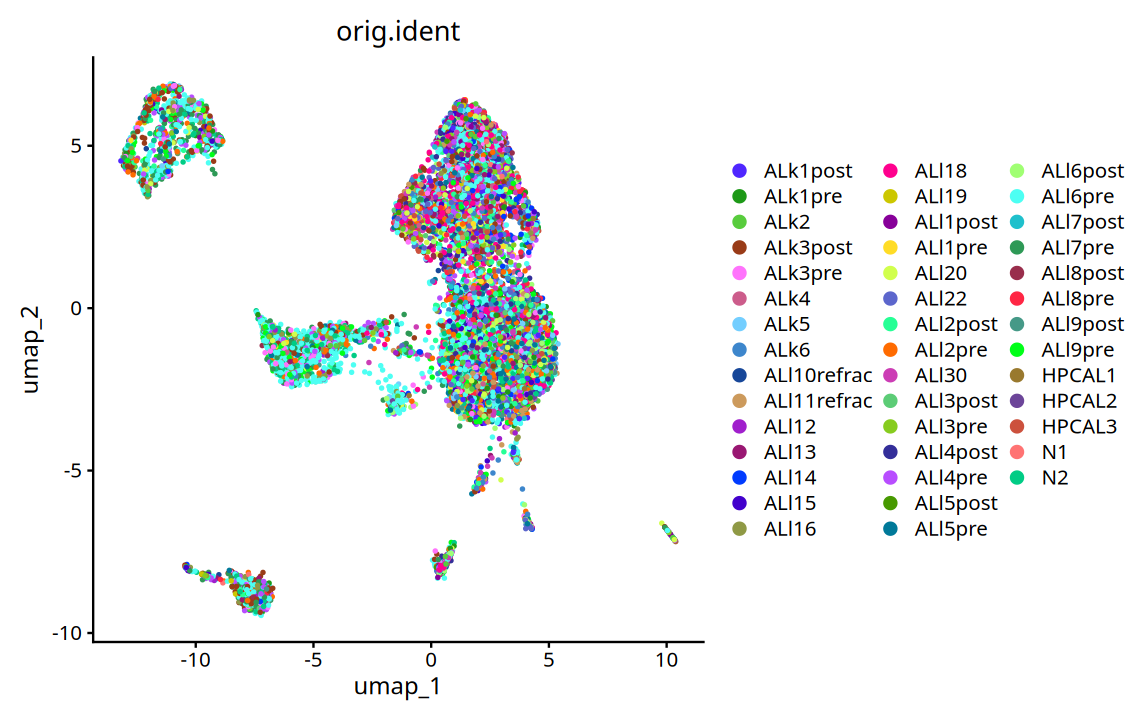

In [47]:
library(scCustomize)
sce1_bcell<-obj
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_bcell, pt.size=0.5,reduction = "umap", group.by = c("orig.ident"),label=F) 

In [48]:
sce1_bcell <- subset(sce1_bcell, idents = c("6","7","8","9","10"), invert = TRUE)

## 13. Packages and setup


In [49]:
library(harmony)
obj<- sce1_bcell
obj <- RunUMAP(obj, reduction = "harmony",dims=1:30)
obj <- FindNeighbors(obj, dims = 1:30, reduction = "harmony")
obj <- FindClusters(obj, resolution = 0.2, cluster.name = "harmony_clusters")

21:52:07 UMAP embedding parameters a = 0.9922 b = 1.112

21:52:07 Read 11953 rows and found 30 numeric columns

21:52:07 Using Annoy for neighbor search, n_neighbors = 30

21:52:07 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:52:08 Writing NN index file to temp file /tmp/RtmpNMQRfF/file745bfa63208

21:52:08 Searching Annoy index using 1 thread, search_k = 3000

21:52:12 Annoy recall = 100%

21:52:13 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

21:52:15 Initializing from normalized Laplacian + noise (using RSpectra)

21:52:15 Commencing optimization for 200 epochs, with 528538 positive edges

21:52:15 Using rng type: pcg

21:52:22 Optimization finished

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 11953
Number of edges: 432761

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9376
Number of communities: 6
Elapsed time: 1 seconds


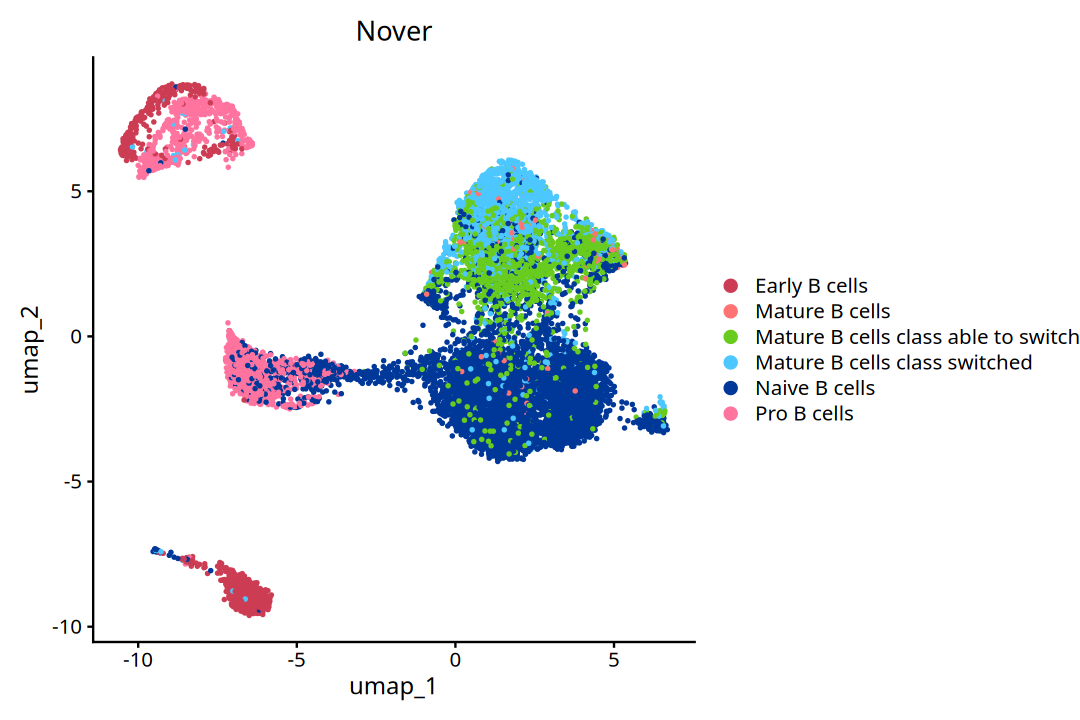

In [50]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9)
sce1_bcell<-obj
celltypes<-sort(unique(sce1_bcell@meta.data$Nover))
DimPlot(sce1_bcell, pt.size=0.5,reduction = "umap", group.by = c("Nover"),label=F,cols=color_cluster_df[celltypes,]$Color) 

In [51]:
sce1_bcell

An object of class Seurat 
36601 features across 11953 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, UMAP, harmony, umap

In [52]:
saveRDS(sce1_bcell, file = "sce1_bcell.rds")

In [53]:
#NK cells

## 14. Cell selection and quality control


In [54]:
sce1_nkcell <- subset(sce1_TME, Nover.lineage %in% "Lymphoid_NKcell")

In [55]:
sce1_nkcell 

An object of class Seurat 
36601 features across 4245 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, UMAP

In [56]:
# Step 3: Proceed with PCA and UMAP
sce1_nkcell <- ScaleData(sce1_nkcell , features = VariableFeatures(sce1_nkcell))
sce1_nkcell <- RunPCA(sce1_nkcell , features = VariableFeatures(sce1_nkcell))

Centering and scaling data matrix

Warning message:
“The following 381 features requested have zero variance; running reduction without them: CXCL12, IGKV3-11, PF4, IGLV2-14, IGLL1, IGHA1, GP1BB, IGKV1D-8, DEFA4, AREG, HIST1H4C, FAM178B, C7, TUBB1, IGHV1-18, HIST1H1B, DEFB1, IGKV1-16, FN1, OLFML3, GYPA, HEMGN, IGHM, CCN1, TRBV4-2, FMO2, IGLC6, IGKV2D-28, PRSS57, TRBV7-6, MYL4, TRBV10-3, TRBV11-1, STMN1, KLF1, HIST1H1D, BGN, IGLVI-70, IGLV3-21, CDC20, ASPM, SERPINE1, ADGRL4, AC011139.1, IGHV3-74, IGLV1-51, LILRA4, TRBV5-1, CCL4, IGHV2-26, TRBV3-1, S100B, IBSP, AKR1C3, HMBS, TRBV5-4, HIST1H3D, PRG3, MMRN1, IGLV3-19, IGHV3-53, IGLV10-54, TRBV6-5, IGHV1-46, TMEM14C, IGKV1OR22-5, FBLN1, RHCE, SFRP4, IGHD, CPA3, CXCL13, H1F0, IFIT1B, IGHV3-43, MYC, MMP9, HES6, TFPI, TPX2, STMN2, EFEMP1, CDKN3, NPY, IGHV3-69-1, IGHV3-15, CHRDL1, GDF15, BIRC5, CD74, TRBV9, RNASE2, IGKV6D-21, PAPPA, CCL20, KRT5, POSTN, LTBP2, PRC1, AKAP12, EBF1, CCL3L1, TRBV7-4, CDH11, S100A12, CCDC80, IGKV2D-24, SLPI, TDO2, TR

## 15. Normalization, integration, and dimensional reduction


In [57]:
sce1_nkcell <- FindNeighbors(sce1_nkcell , dims = 1:15, reduction = "pca")
sce1_nkcell <- FindClusters(sce1_nkcell , resolution =0.3, cluster.name = "seurat_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4245
Number of edges: 155069

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8936
Number of communities: 9
Elapsed time: 0 seconds


In [58]:
sce1_nkcell <- RunUMAP(sce1_nkcell , dims = 1:15, reduction = "pca", reduction.name = "UMAP")

21:53:21 UMAP embedding parameters a = 0.9922 b = 1.112

21:53:21 Read 4245 rows and found 15 numeric columns

21:53:21 Using Annoy for neighbor search, n_neighbors = 30

21:53:21 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:53:22 Writing NN index file to temp file /tmp/RtmpNMQRfF/file745b68e410ad

21:53:22 Searching Annoy index using 1 thread, search_k = 3000

21:53:23 Annoy recall = 100%

21:53:24 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

21:53:26 Initializing from normalized Laplacian + noise (using RSpectra)

21:53:26 Commencing optimization for 500 epochs, with 176382 positive edges

21:53:26 Using rng type: pcg

21:53:32 Optimization finished



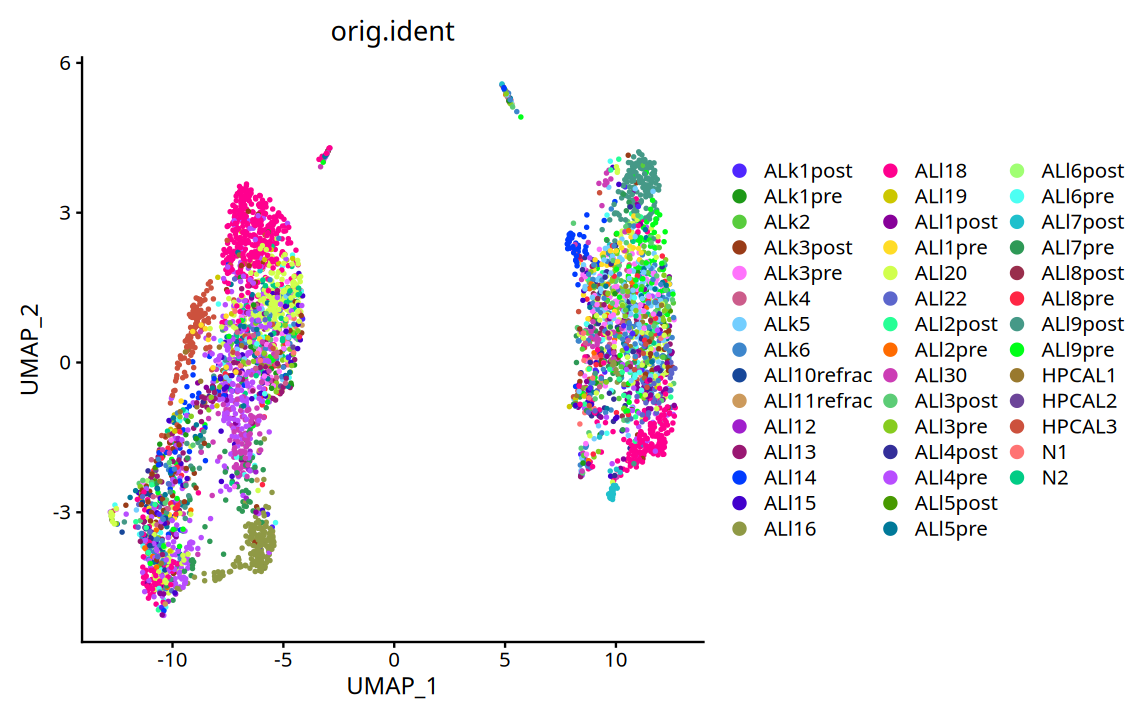

In [59]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_nkcell , pt.size=0.5,reduction = "UMAP", group.by = c("orig.ident"),label=F) 

In [60]:
library(harmony)
obj<-sce1_nkcell
obj <- RunHarmony(obj, "orig.ident")
obj <- RunUMAP(obj, reduction = "harmony",dims=1:30)
obj <- FindNeighbors(obj, dims = 1:30, reduction = "harmony")
obj <- FindClusters(obj, resolution = 1, cluster.name = "harmony_clusters")

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

21:53:35 UMAP embedding parameters a = 0.9922 b = 1.112

21:53:35 Read 4245 rows and found 30 numeric columns

21:53:35 Using Annoy for neighbor search, n_neighbors = 30

21:53:35 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:53:36 Writing NN index file to temp file /tmp/RtmpNMQRfF/file745b10b263e

21:53:36 Searching Annoy index using 1 thread, search_k = 3000

21:53:37 Annoy recall = 100%

21:53:38 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

21:53:40 Initializing from normalized Laplacian + noise (using RSpectra)

21:53:40 Commencing optimization for 500 epo

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4245
Number of edges: 186694

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7119
Number of communities: 13
Elapsed time: 0 seconds


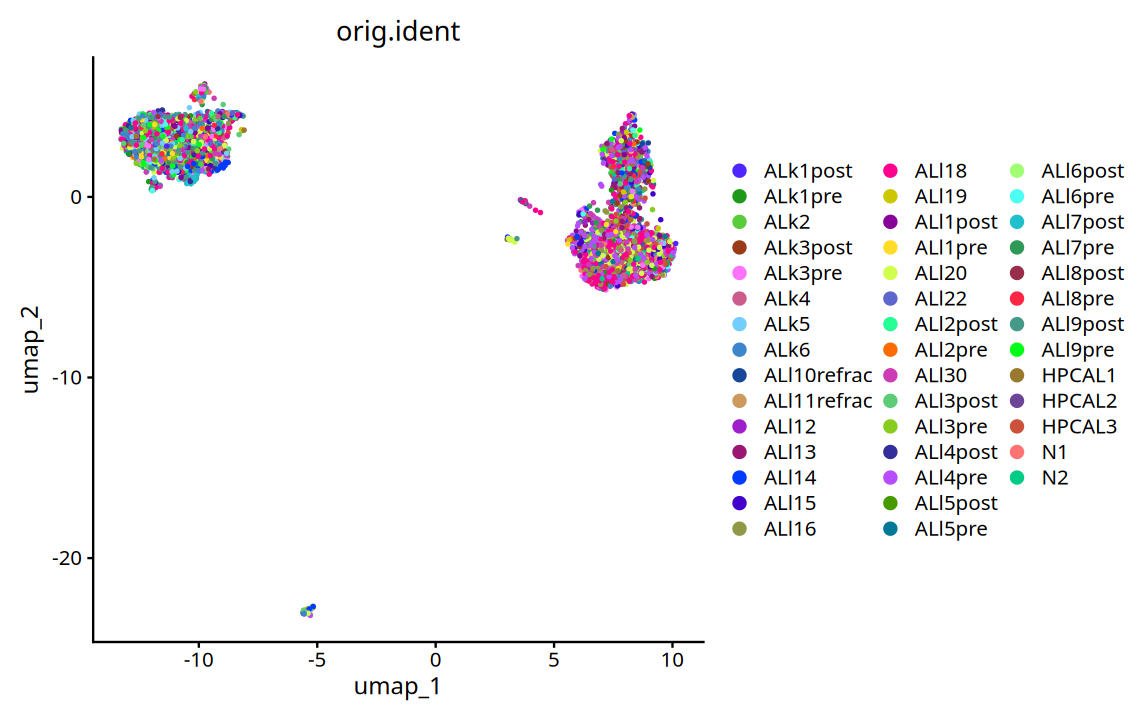

In [61]:
library(scCustomize)
sce1_nkcell<-obj
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_nkcell, pt.size=0.5,reduction = "umap", group.by = c("orig.ident"),label=F) 

## 16. Visualization and figure generation


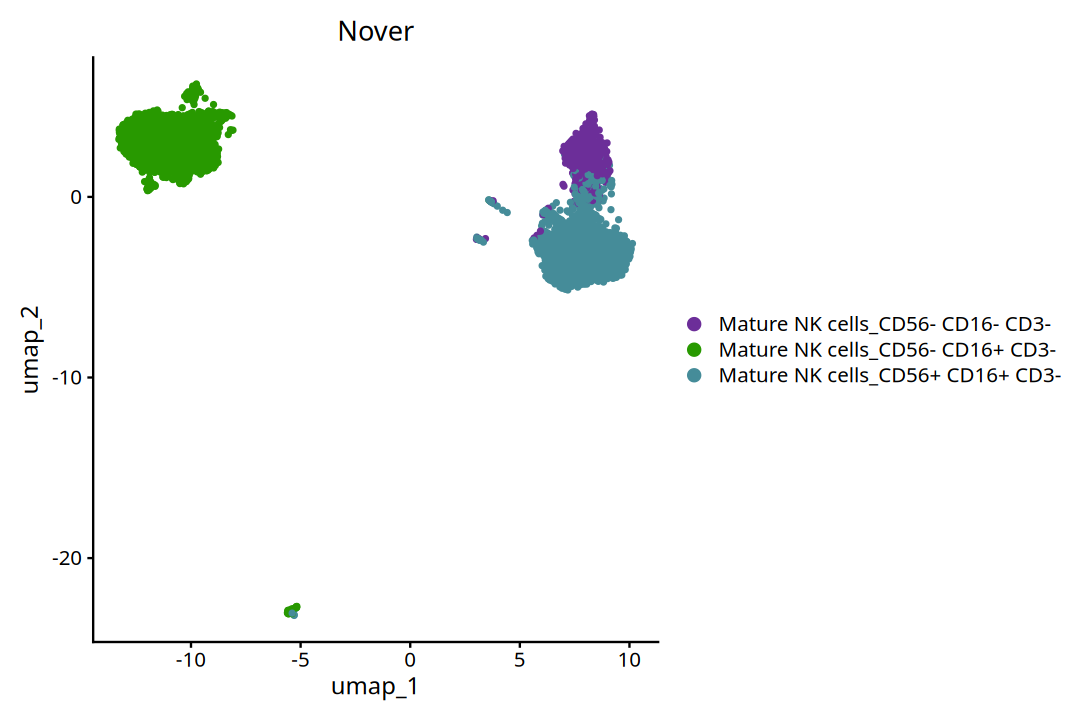

In [62]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9)
celltypes<-sort(unique(sce1_nkcell@meta.data$Nover))
DimPlot(sce1_nkcell, pt.size=1,reduction = "umap", group.by = c("Nover"),label=F,cols=color_cluster_df[celltypes,]$Color) 

In [63]:
sce1_nkcell

An object of class Seurat 
36601 features across 4245 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, UMAP, harmony, umap

In [64]:
saveRDS(sce1_nkcell, file = "sce1_nkcell.rds")

## 17. Dentritic/Monocytes


In [65]:
#Dentritic/Monocytes

In [66]:
# Subset all cells with "myeloid" in their lineage name (case-insensitive)

sce1_myeloid  <- subset(sce1_TME, Nover.lineage %in% c("Myeloid_Dendritic","Myeloid_Progenitors",'HSPC',"Myeloid_Granulocyte"))

In [67]:
sce1_myeloid 

An object of class Seurat 
36601 features across 139776 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, UMAP

In [68]:
# Step 3: Proceed with PCA and UMAP
sce1_myeloid <- ScaleData(sce1_myeloid , features = VariableFeatures(sce1_myeloid ))
sce1_myeloid <- RunPCA(sce1_myeloid , features = VariableFeatures(sce1_myeloid ))

Centering and scaling data matrix

Warning message:
“The following 49 features requested have zero variance; running reduction without them: IGLL1, HIST1H1D, BGN, IGHV3-74, LILRA4, S100B, HIST1H3D, MMRN1, TMEM14C, IGKV1OR22-5, PRKAR2B, TRBV9, RNASE2, C19orf33, COL6A3, LGALSL, NUF2, AURKB, XPO7, CEACAM8, PAX5, STAB2, DPT, C19orf48, MCM6, RTKN2, NSD2, AC114752.2, PCDHB6, TAC3, ADIPOQ, SLIRP, LMNB1, TRH, GPR88, IGHV3-35, RIF1, AL162424.1, EMP2, FOSB, TMPO, MEOX2, AL592182.3, FOXM1, PCAT18, WRN, MEF2C, LINC00640, ZMYND8”
PC_ 1 
Positive:  RPLP0, PTMA, NME2, PPIA, EEF1B2, HNRNPA1, YBX1, HSP90AB1, RPS17, NPM1 
	   HLA-DRA, CD74, MIF, LDHB, SLC25A5, HLA-DRB1, RPL23, RAN, HLA-DPA1, SNHG29 
	   STMN1, HLA-DPB1, NCL, HSP90B1, CALR, ATP5MC3, PEBP1, NUCKS1, SNRPF, LGALS1 
Negative:  S100A8, S100A9, IFITM2, FCGR3B, G0S2, CXCR2, CYP4F3, S100P, CMTM2, SOD2 
	   S100A12, PGLYRP1, RGS2, ANXA3, NAMPT, MMP9, PTGS2, VNN2, AQP9, SLC25A37 
	   PROK2, ACSL1, CRISP3, STEAP4, MME, IL1R2, C5AR1, LUCAT1, CAMP, F

In [69]:
sce1_myeloid <- FindNeighbors(sce1_myeloid , dims = 1:15, reduction = "pca")
sce1_myeloid <- FindClusters(sce1_myeloid , resolution =0.3, cluster.name = "seurat_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 139776
Number of edges: 4057927

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9436
Number of communities: 17
Elapsed time: 84 seconds


## 18. Normalization, integration, and dimensional reduction


In [70]:
sce1_myeloid <- RunUMAP(sce1_myeloid , dims = 1:15, reduction = "pca", reduction.name = "UMAP")

21:57:28 UMAP embedding parameters a = 0.9922 b = 1.112

21:57:28 Read 139776 rows and found 15 numeric columns

21:57:28 Using Annoy for neighbor search, n_neighbors = 30

21:57:28 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:57:43 Writing NN index file to temp file /tmp/RtmpNMQRfF/file745b906b1ce

21:57:43 Searching Annoy index using 1 thread, search_k = 3000

21:58:45 Annoy recall = 100%

21:58:46 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

21:58:52 Initializing from normalized Laplacian + noise (using RSpectra)

21:59:18 Commencing optimization for 200 epochs, with 6185416 positive edges

21:59:18 Using rng type: pcg

22:00:49 Optimization finished



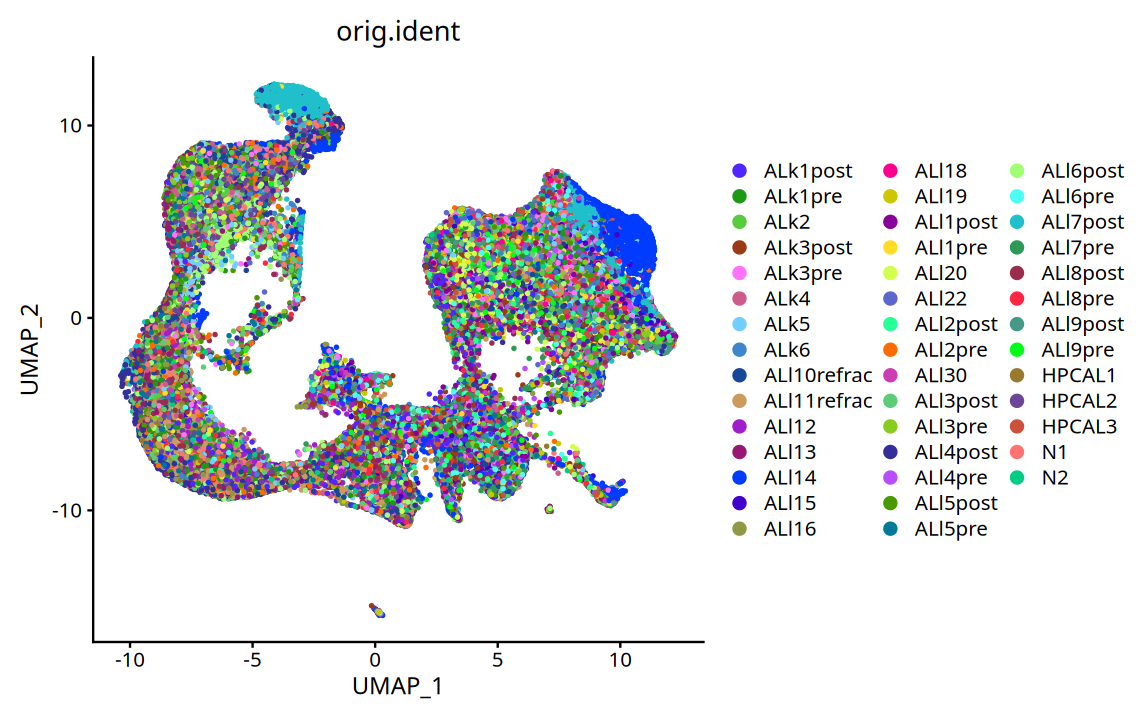

In [71]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_myeloid , pt.size=0.5,reduction = "UMAP", group.by = c("orig.ident"),label=F) 

In [72]:
library(harmony)
obj<-sce1_myeloid
obj <- RunHarmony(obj, "orig.ident")
obj <- RunUMAP(obj, reduction = "harmony",dims=1:30)
obj <- FindNeighbors(obj, dims = 1:30, reduction = "harmony")
obj <- FindClusters(obj, resolution = 1, cluster.name = "harmony_clusters")

Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 6988800)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 6988800)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 6988800)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

22:03:18 UMAP embedding parameters a = 0.9922 b = 1.112

22:03:18 Read 139776 rows and found 30 numeric columns

22:03:18 Using Annoy for neighbor search, n_neighbors = 30

22:03:18 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

22:03:36 Writing NN index file to temp file /tmp/RtmpNMQRfF/file745b6b49661d

22:03:36 Searching Annoy index using 1 thread, search_k = 3000

22:04:39 Annoy rec

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 139776
Number of edges: 4180256

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8884
Number of communities: 32
Elapsed time: 61 seconds


3 singletons identified. 29 final clusters.



## 19. Visualization and figure generation


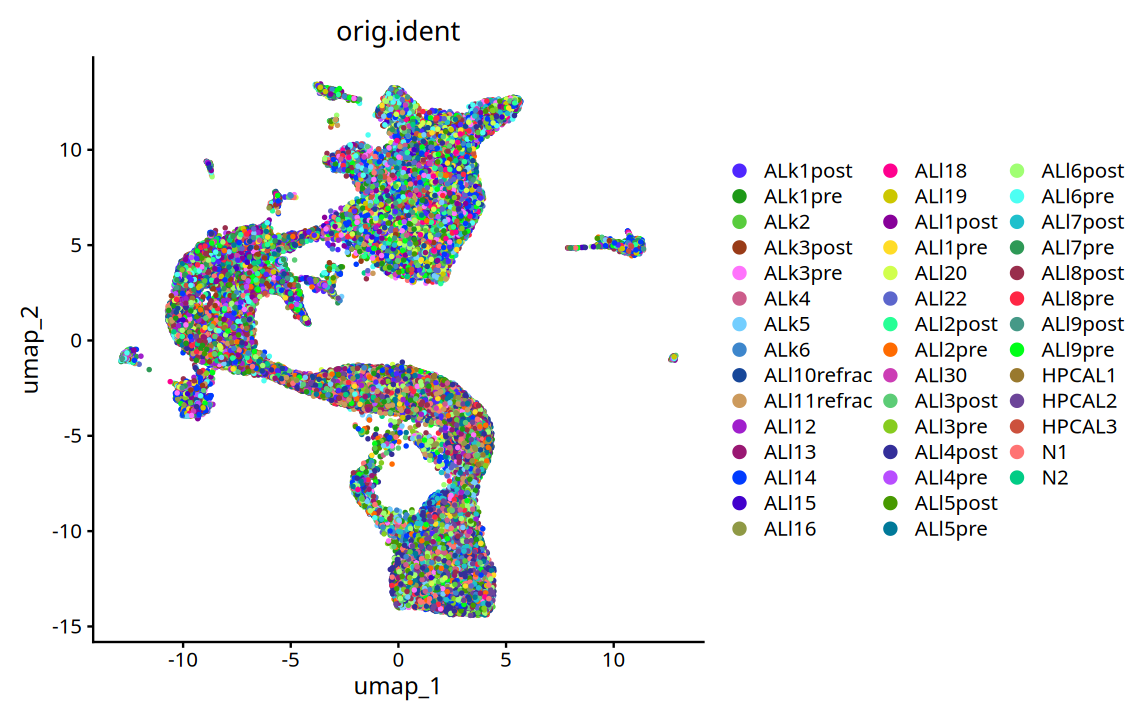

In [73]:
library(scCustomize)
sce1_myeloid<-obj
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_myeloid, pt.size=0.5,reduction = "umap", group.by = c("orig.ident"),label=F) 

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



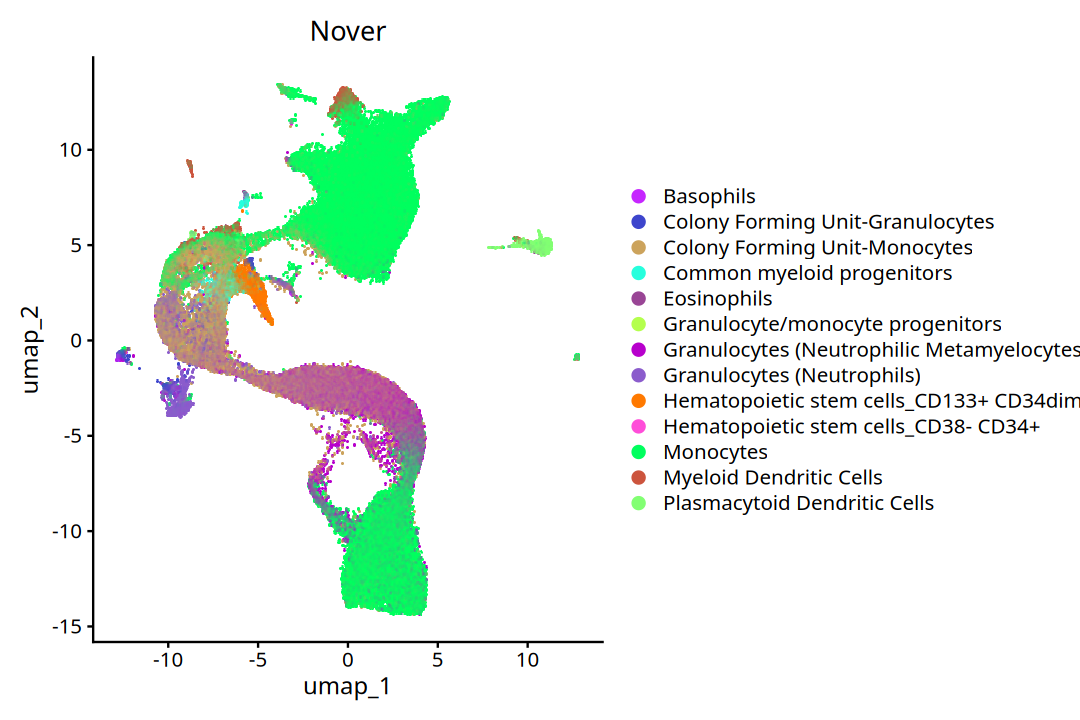

In [74]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9)
celltypes<-sort(unique(sce1_myeloid@meta.data$Nover))
DimPlot(sce1_myeloid, pt.size=2,reduction = "umap", group.by = c("Nover"),label=F,cols=color_cluster_df[celltypes,]$Color) 

In [75]:
sce1_myeloid

An object of class Seurat 
36601 features across 139776 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, UMAP, harmony, umap

In [76]:
saveRDS(sce1_myeloid, file = "sce1_myeloid.rds")

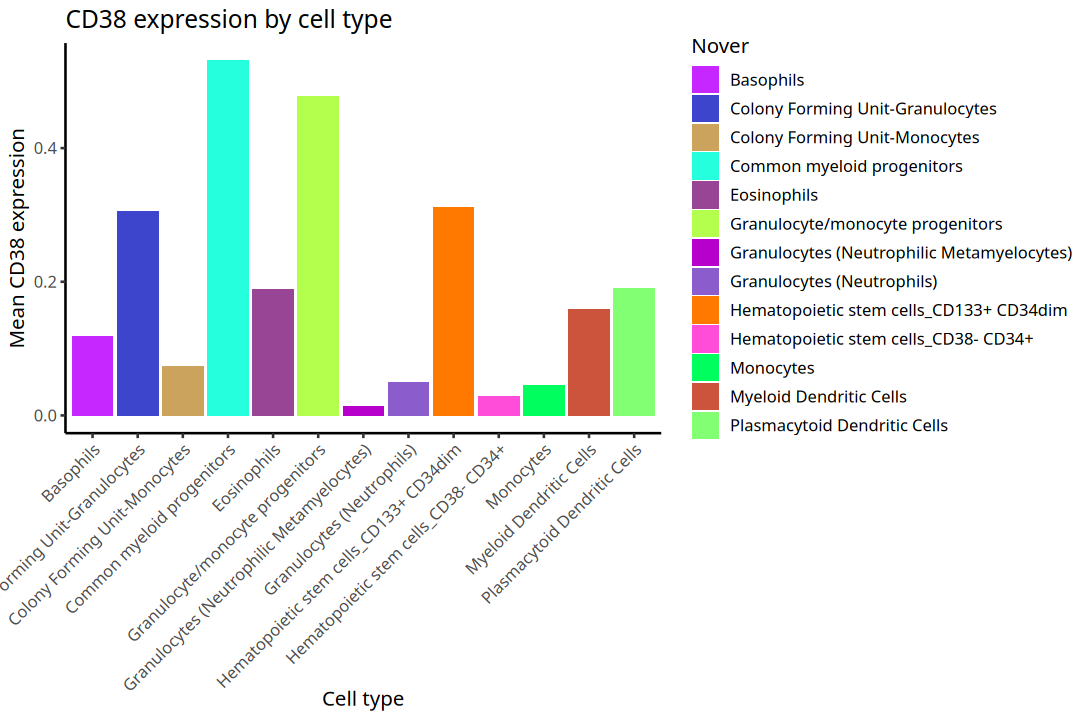

In [77]:
library(Seurat)
library(dplyr)
library(ggplot2)

# 1) Extract CD38 expression + cell type info
cd38_expr <- FetchData(sce1_myeloid, vars = c("CD38", "Nover"))  # replace Nover with your cell type column if needed

# 2) Summarize average CD38 expression by cell type
cd38_summary <- cd38_expr %>%
  group_by(Nover) %>%
  summarise(mean_CD38 = mean(CD38, na.rm = TRUE))

# 3) Make sure colors align with celltypes
celltypes <- sort(unique(sce1_myeloid@meta.data$Nover))   # same as in your DimPlot
cell_colors <- setNames(color_cluster_df[celltypes, ]$Color, celltypes)

# 4) Plot barplot with custom colors
ggplot(cd38_summary, aes(x = Nover, y = mean_CD38, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean CD38 expression",
       title = "CD38 expression by cell type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


## 20. Visualization and figure generation


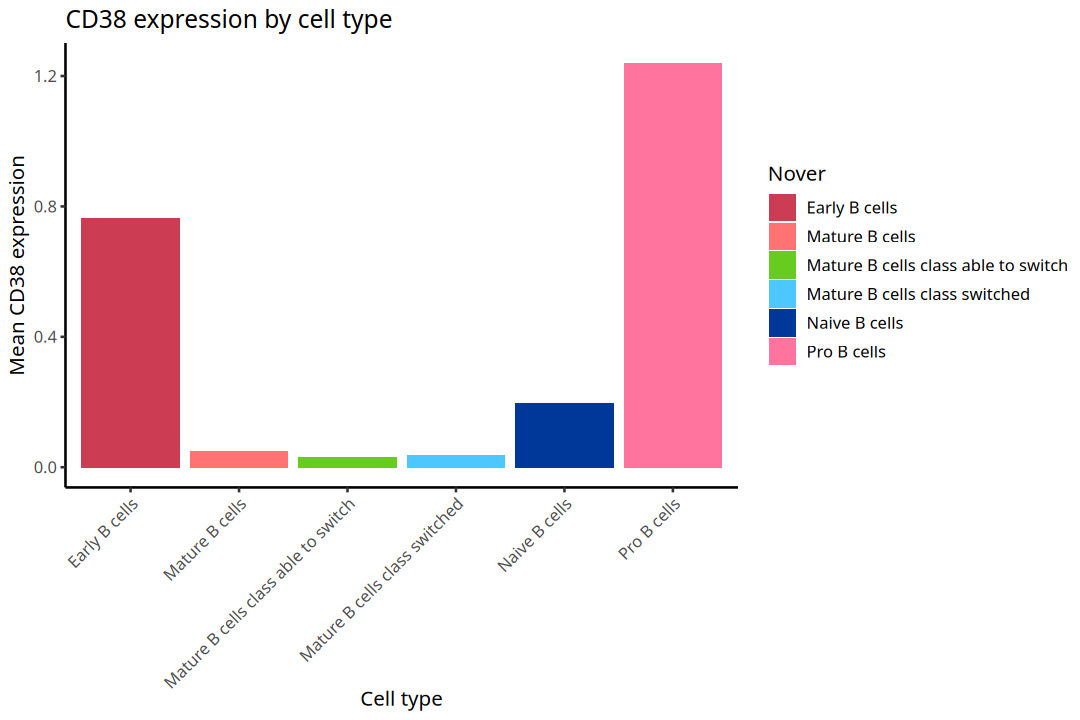

In [78]:
library(Seurat)
library(dplyr)
library(ggplot2)

# 1) Extract CD38 expression + cell type info
cd38_expr <- FetchData(sce1_bcell, vars = c("CD38", "Nover"))  # replace Nover with your cell type column if needed

# 2) Summarize average CD38 expression by cell type
cd38_summary <- cd38_expr %>%
  group_by(Nover) %>%
  summarise(mean_CD38 = mean(CD38, na.rm = TRUE))

# 3) Make sure colors align with celltypes
celltypes <- sort(unique(sce1_bcell@meta.data$Nover))   # same as in your DimPlot
cell_colors <- setNames(color_cluster_df[celltypes, ]$Color, celltypes)

# 4) Plot barplot with custom colors
ggplot(cd38_summary, aes(x = Nover, y = mean_CD38, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean CD38 expression",
       title = "CD38 expression by cell type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


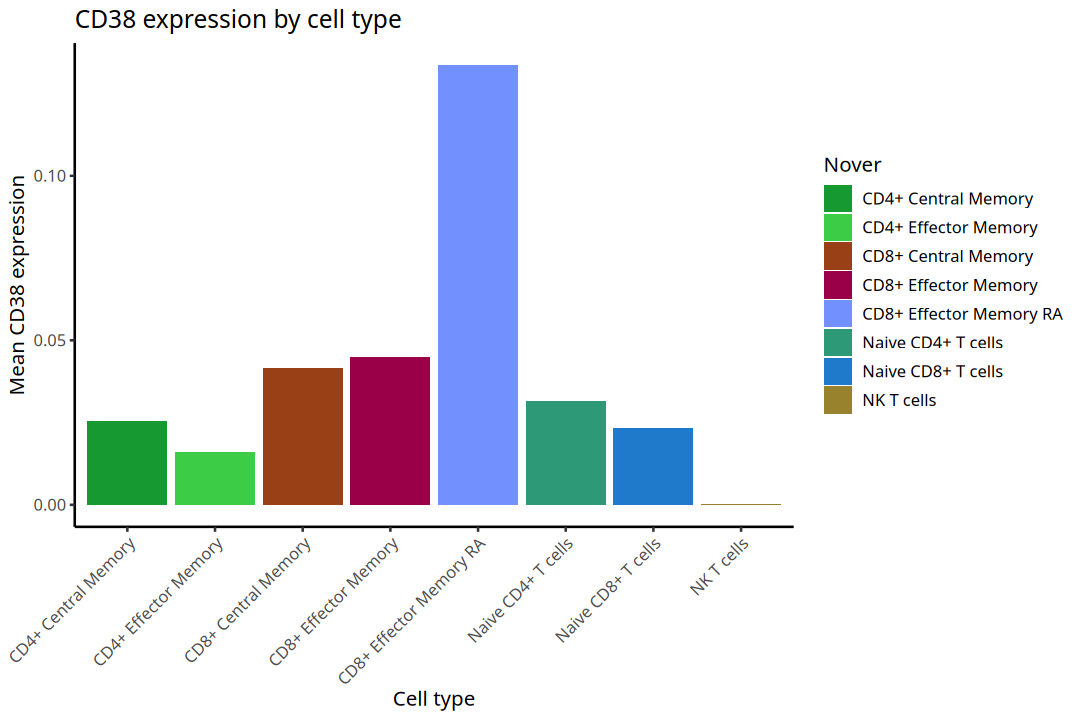

In [79]:
library(Seurat)
library(dplyr)
library(ggplot2)

# 1) Extract CD38 expression + cell type info
cd38_expr <- FetchData(sce1_tcell, vars = c("CD38", "Nover"))  # replace Nover with your cell type column if needed

# 2) Summarize average CD38 expression by cell type
cd38_summary <- cd38_expr %>%
  group_by(Nover) %>%
  summarise(mean_CD38 = mean(CD38, na.rm = TRUE))

# 3) Make sure colors align with celltypes
celltypes <- sort(unique(sce1_tcell@meta.data$Nover))   # same as in your DimPlot
cell_colors <- setNames(color_cluster_df[celltypes, ]$Color, celltypes)

# 4) Plot barplot with custom colors
ggplot(cd38_summary, aes(x = Nover, y = mean_CD38, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean CD38 expression",
       title = "CD38 expression by cell type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


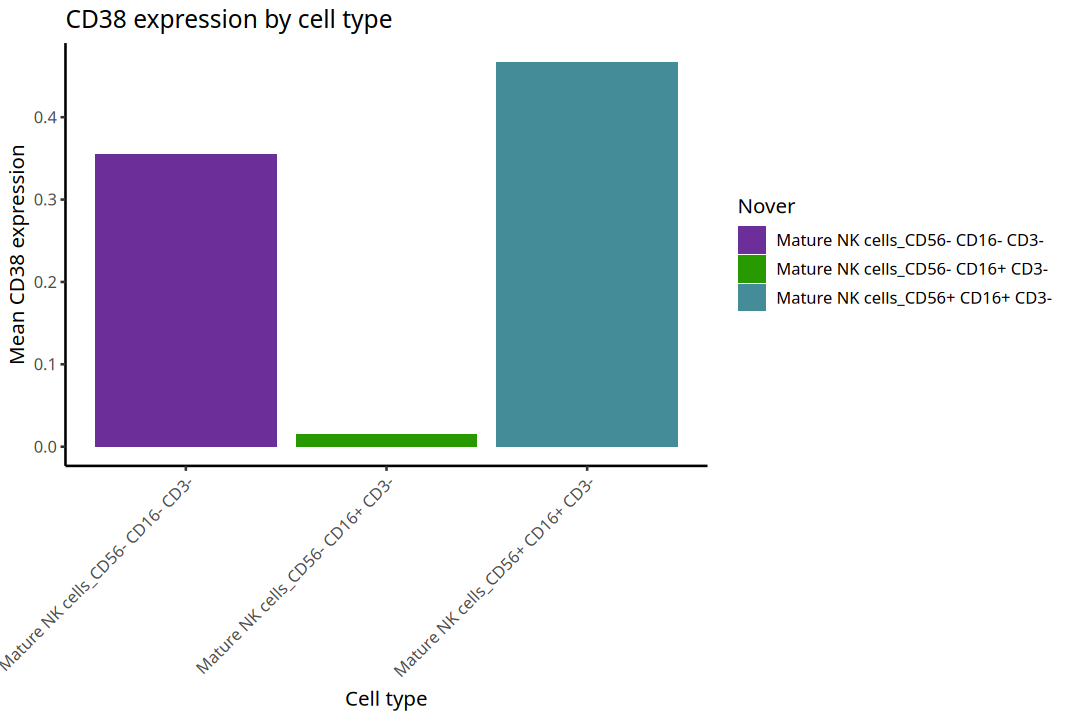

In [80]:
library(Seurat)
library(dplyr)
library(ggplot2)

# 1) Extract CD38 expression + cell type info
cd38_expr <- FetchData(sce1_nkcell, vars = c("CD38", "Nover"))  # replace Nover with your cell type column if needed

# 2) Summarize average CD38 expression by cell type
cd38_summary <- cd38_expr %>%
  group_by(Nover) %>%
  summarise(mean_CD38 = mean(CD38, na.rm = TRUE))

# 3) Make sure colors align with celltypes
celltypes <- sort(unique(sce1_nkcell@meta.data$Nover))   # same as in your DimPlot
cell_colors <- setNames(color_cluster_df[celltypes, ]$Color, celltypes)

# 4) Plot barplot with custom colors
ggplot(cd38_summary, aes(x = Nover, y = mean_CD38, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean CD38 expression",
       title = "CD38 expression by cell type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


## 21. Visualization and figure generation


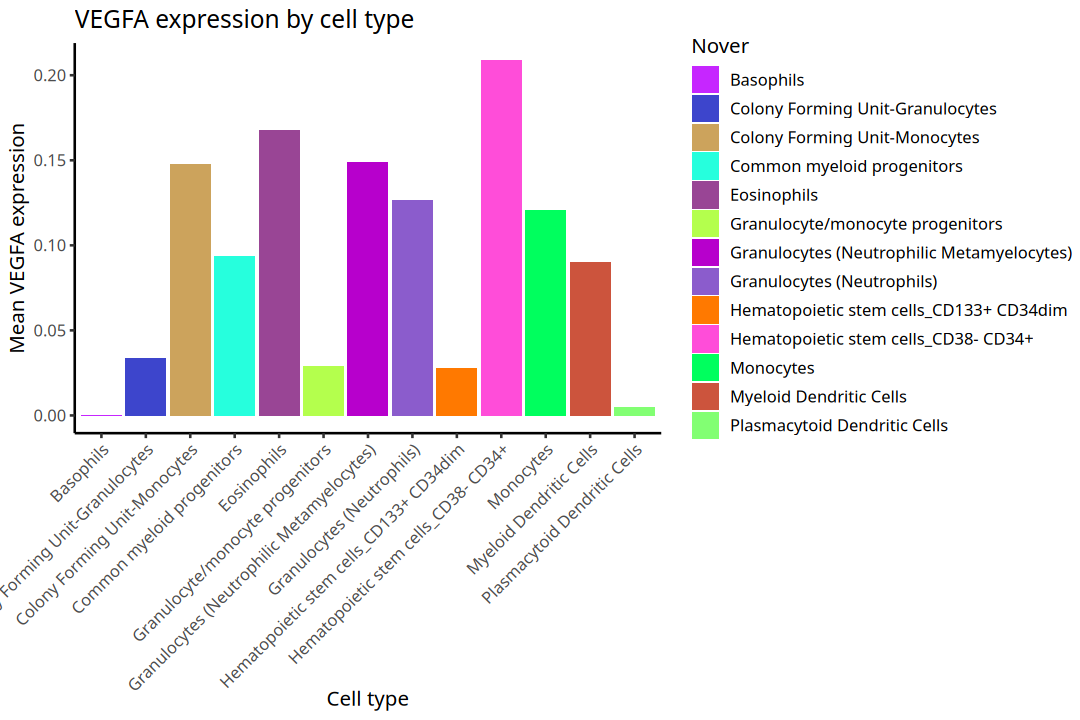

In [81]:
library(Seurat)
library(dplyr)
library(ggplot2)

# 1) Extract VEGFA expression + cell type info
VEGFA_expr <- FetchData(sce1_myeloid, vars = c("VEGFA", "Nover"))  # replace Nover with your cell type column if needed

# 2) Summarize average VEGFA expression by cell type
VEGFA_summary <- VEGFA_expr %>%
  group_by(Nover) %>%
  summarise(mean_VEGFA = mean(VEGFA, na.rm = TRUE))

# 3) Make sure colors align with celltypes
celltypes <- sort(unique(sce1_myeloid@meta.data$Nover))   # same as in your DimPlot
cell_colors <- setNames(color_cluster_df[celltypes, ]$Color, celltypes)

# 4) Plot barplot with custom colors
ggplot(VEGFA_summary, aes(x = Nover, y = mean_VEGFA, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean VEGFA expression",
       title = "VEGFA expression by cell type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


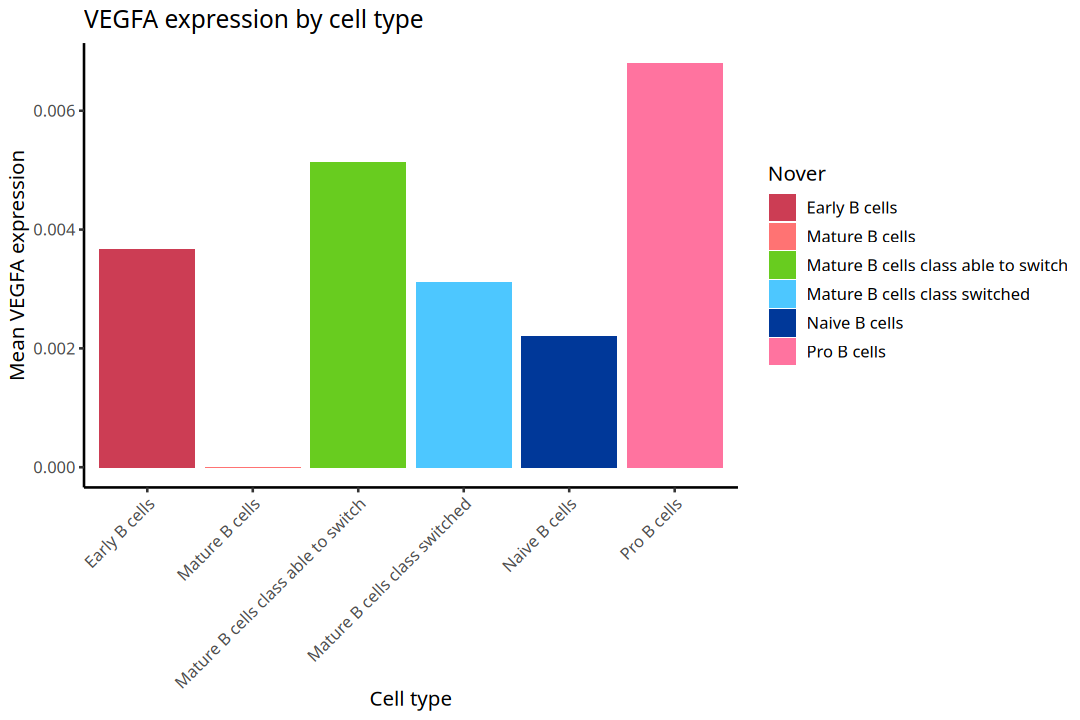

In [82]:
library(Seurat)
library(dplyr)
library(ggplot2)

# 1) Extract VEGFA expression + cell type info
VEGFA_expr <- FetchData(sce1_bcell, vars = c("VEGFA", "Nover"))  # replace Nover with your cell type column if needed

# 2) Summarize average VEGFA expression by cell type
VEGFA_summary <- VEGFA_expr %>%
  group_by(Nover) %>%
  summarise(mean_VEGFA = mean(VEGFA, na.rm = TRUE))

# 3) Make sure colors align with celltypes
celltypes <- sort(unique(sce1_bcell@meta.data$Nover))   # same as in your DimPlot
cell_colors <- setNames(color_cluster_df[celltypes, ]$Color, celltypes)

# 4) Plot barplot with custom colors
ggplot(VEGFA_summary, aes(x = Nover, y = mean_VEGFA, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean VEGFA expression",
       title = "VEGFA expression by cell type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


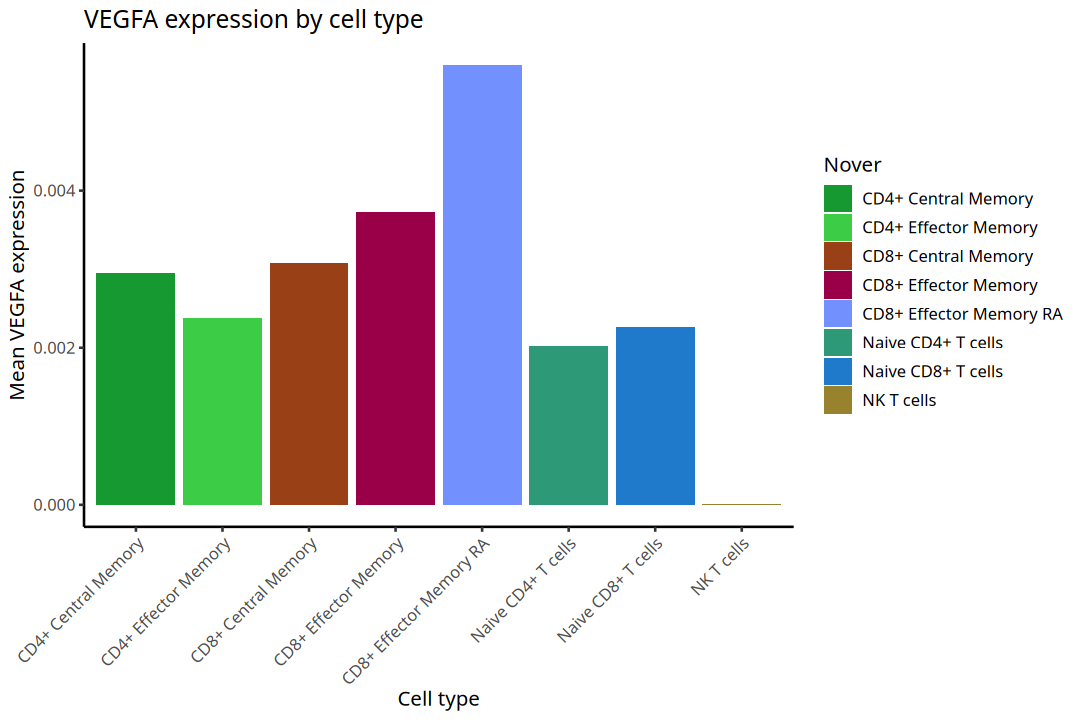

In [83]:
library(Seurat)
library(dplyr)
library(ggplot2)

# 1) Extract VEGFA expression + cell type info
VEGFA_expr <- FetchData(sce1_tcell, vars = c("VEGFA", "Nover"))  # replace Nover with your cell type column if needed

# 2) Summarize average VEGFA expression by cell type
VEGFA_summary <- VEGFA_expr %>%
  group_by(Nover) %>%
  summarise(mean_VEGFA = mean(VEGFA, na.rm = TRUE))

# 3) Make sure colors align with celltypes
celltypes <- sort(unique(sce1_tcell@meta.data$Nover))   # same as in your DimPlot
cell_colors <- setNames(color_cluster_df[celltypes, ]$Color, celltypes)

# 4) Plot barplot with custom colors
ggplot(VEGFA_summary, aes(x = Nover, y = mean_VEGFA, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean VEGFA expression",
       title = "VEGFA expression by cell type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


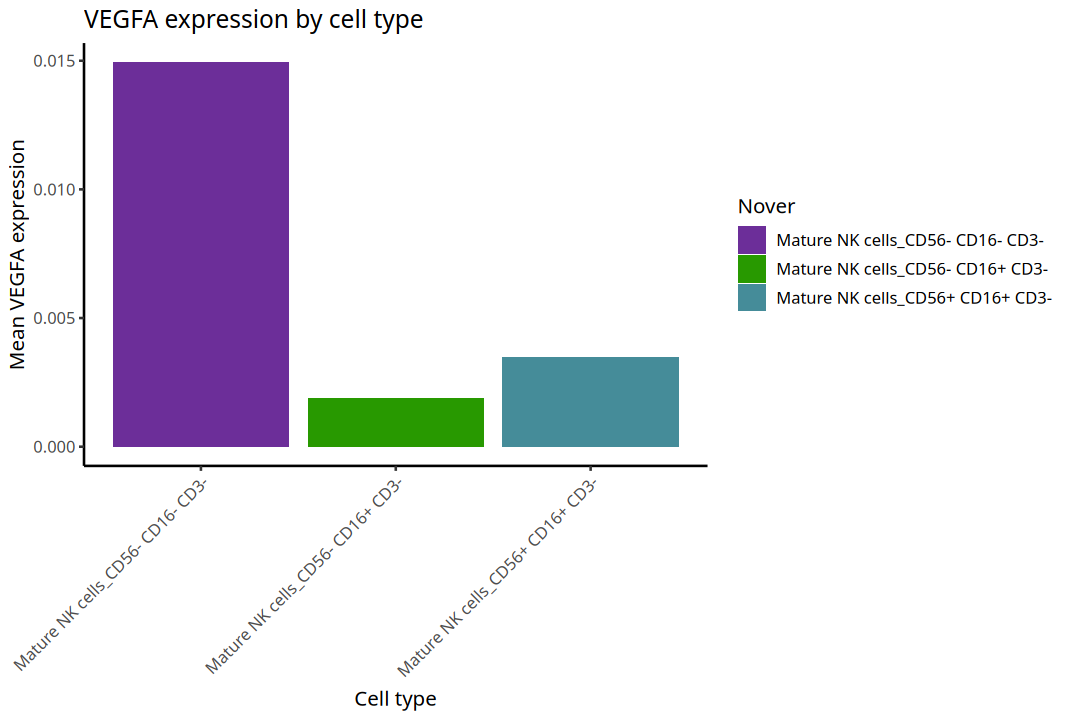

In [84]:
library(Seurat)
library(dplyr)
library(ggplot2)

# 1) Extract VEGFA expression + cell type info
VEGFA_expr <- FetchData(sce1_nkcell, vars = c("VEGFA", "Nover"))  # replace Nover with your cell type column if needed

# 2) Summarize average VEGFA expression by cell type
VEGFA_summary <- VEGFA_expr %>%
  group_by(Nover) %>%
  summarise(mean_VEGFA = mean(VEGFA, na.rm = TRUE))

# 3) Make sure colors align with celltypes
celltypes <- sort(unique(sce1_nkcell@meta.data$Nover))   # same as in your DimPlot
cell_colors <- setNames(color_cluster_df[celltypes, ]$Color, celltypes)

# 4) Plot barplot with custom colors
ggplot(VEGFA_summary, aes(x = Nover, y = mean_VEGFA, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(x = "Cell type", y = "Mean VEGFA expression",
       title = "VEGFA expression by cell type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


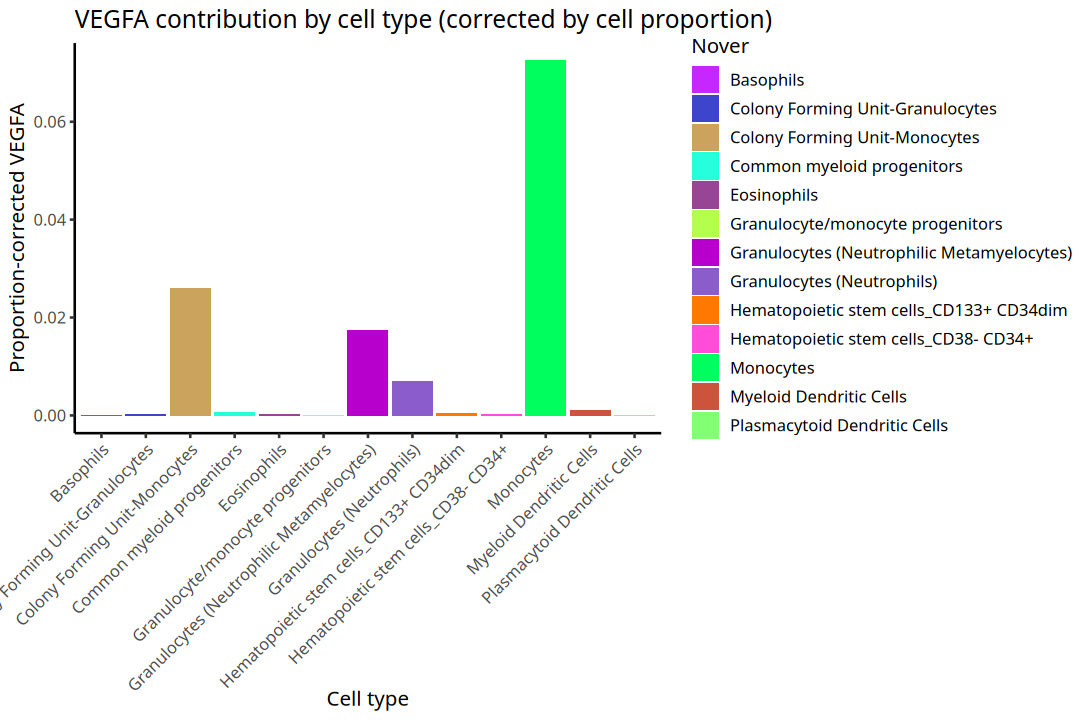

In [85]:
library(Seurat)
library(dplyr)
library(ggplot2)

# 1) Extract VEGFA expression + cell type info
VEGFA_expr <- FetchData(sce1_myeloid, vars = c("VEGFA", "Nover"))

# 2) Summarize mean expression + cell proportion by cell type
VEGFA_summary <- VEGFA_expr %>%
  group_by(Nover) %>%
  summarise(
    n_cells = n(),
    mean_VEGFA = mean(VEGFA, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    cell_prop = n_cells / sum(n_cells),
    prop_corrected_VEGFA = mean_VEGFA * cell_prop
  )

# Optional: convert to fraction of total corrected VEGFA contribution
VEGFA_summary <- VEGFA_summary %>%
  mutate(
    contribution_frac = prop_corrected_VEGFA / sum(prop_corrected_VEGFA)
  )

# 3) Make sure colors align with cell types
celltypes <- VEGFA_summary$Nover
cell_colors <- setNames(color_cluster_df[celltypes, "Color"], celltypes)

# 4) Plot proportion-corrected VEGFA contribution
ggplot(VEGFA_summary, aes(x = Nover, y = prop_corrected_VEGFA, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(
    x = "Cell type",
    y = "Proportion-corrected VEGFA",
    title = "VEGFA contribution by cell type (corrected by cell proportion)"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## 22. Visualization and figure generation


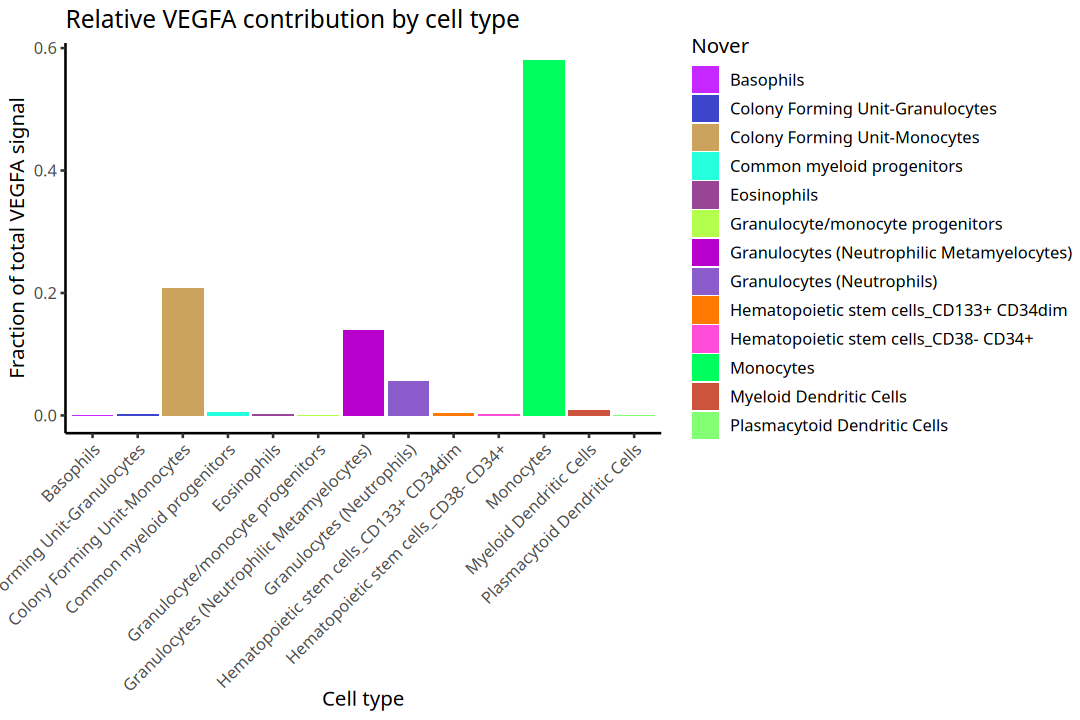

In [86]:
ggplot(VEGFA_summary, aes(x = Nover, y = contribution_frac, fill = Nover)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_colors) +
  theme_classic(base_size = 12) +
  labs(
    x = "Cell type",
    y = "Fraction of total VEGFA signal",
    title = "Relative VEGFA contribution by cell type"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))